## 강원도 신재생에너지 개발 현황 데이터 분석
이 프로젝트는 강원도 내 신재생에너지 발전 설비 현황, 발전 성과,
정책 지원, 기상 요인을 종합하여 지역별 개발 특성과
향후 개발 가능성을 분석하는 것을 목표로 한다.

### 분석 흐름
1. 발전 설비 현황 수집
2. 발전량 데이터 결합
3. 정책·지원 사업 반영
4. 기상 요인 영향 분석

In [19]:
print(energy.columns)
print(energy.head())

Index(['연도', '광역지자체', '기초지자체', '신재생에너지 합계', '재생에너지 합계', '신에너지 합계',
       '신재생에너지공급비중', '태양광', '풍력', '수력', '해양', '바이오', '재생폐기물', '연료전지', 'IGCC'],
      dtype='object')
     연도 광역지자체 기초지자체  신재생에너지 합계   재생에너지 합계  신에너지 합계  신재생에너지공급비중      태양광  \
0  2021    강원   강릉시  2,088,289  2,088,224       65       35.46  131,258   
1  2021    강원   고성군    142,575    142,575        -        2.42  141,704   
2  2021    강원    기타      4,429      4,403       26        0.08    2,769   
3  2021    강원   동해시    405,359    273,611  131,748        6.88   26,993   
4  2021    강원   삼척시    280,341    280,337        3        4.76  110,382   

       풍력      수력 해양        바이오 재생폐기물     연료전지 IGCC  
0  81,395   3,230  -  1,872,341     -       65    -  
1       -     871  -          -     -        -    -  
2   1,634       -  -          -     -       26    -  
3       -  30,284  -    216,335     -  131,748    -  
4  33,271  13,449  -    123,235     -        3    -  


=== 개선된 데이터 정보 ===
병합된 데이터 행 수: 6
매칭된 지역 수: 2
매칭된 지역: ['강릉시', '삼척시']

활용된 관측소: ['강릉']


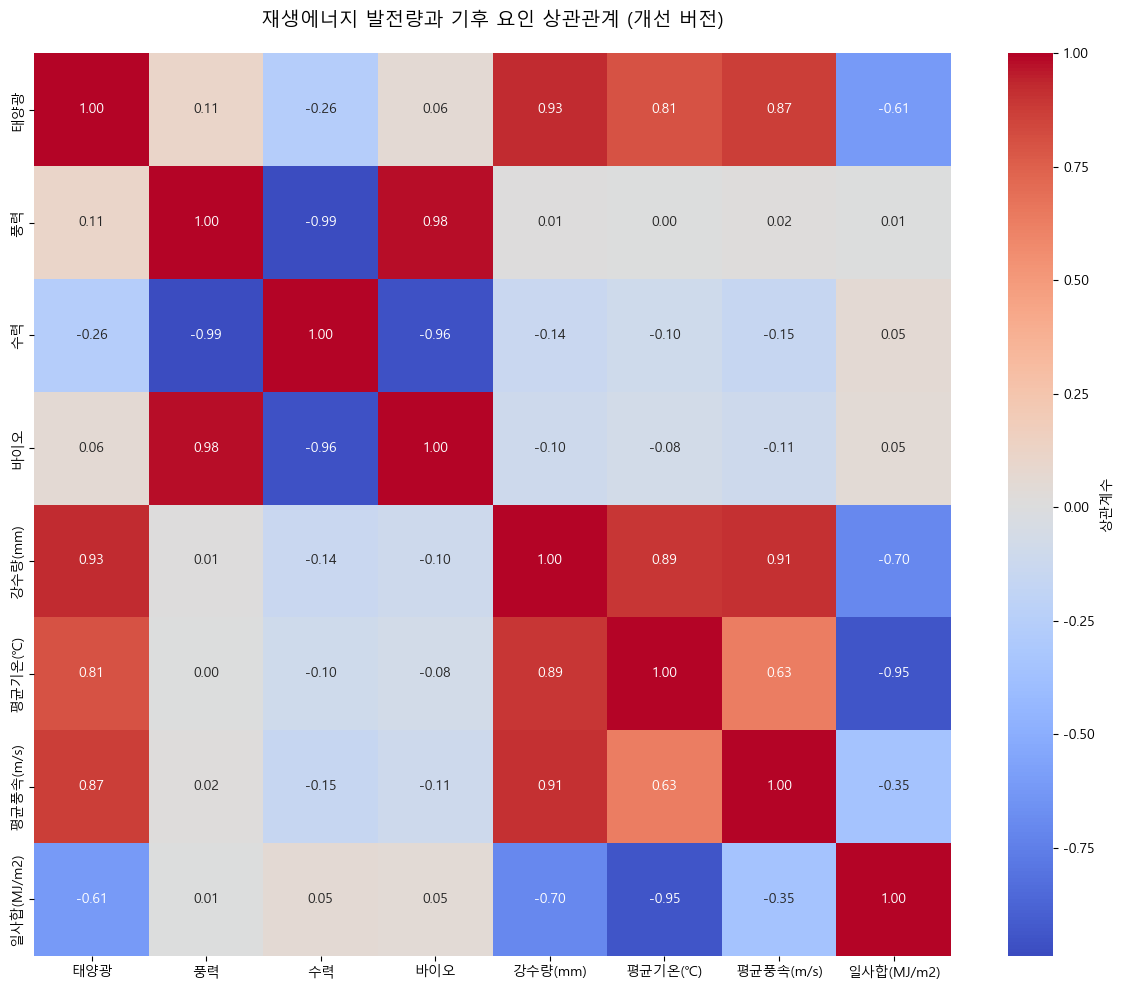


📊 상관관계 테이블:
                 태양광        풍력        수력       바이오   강수량(mm)   평균기온(℃)  \
태양광         1.000000  0.114074 -0.259332  0.058574  0.928218  0.805411   
풍력          0.114074  1.000000 -0.987476  0.979367  0.012227  0.001820   
수력         -0.259332 -0.987476  1.000000 -0.962586 -0.139346 -0.097035   
바이오         0.058574  0.979367 -0.962586  1.000000 -0.103113 -0.078974   
강수량(mm)     0.928218  0.012227 -0.139346 -0.103113  1.000000  0.893627   
평균기온(℃)     0.805411  0.001820 -0.097035 -0.078974  0.893627  1.000000   
평균풍속(m/s)   0.870113  0.019409 -0.152212 -0.106150  0.913953  0.634597   
일사합(MJ/m2) -0.613010  0.005880  0.054120  0.051431 -0.701588 -0.946773   

            평균풍속(m/s)  일사합(MJ/m2)  
태양광          0.870113   -0.613010  
풍력           0.019409    0.005880  
수력          -0.152212    0.054120  
바이오         -0.106150    0.051431  
강수량(mm)      0.913953   -0.701588  
평균기온(℃)      0.634597   -0.946773  
평균풍속(m/s)    1.000000   -0.352039  
일사합(MJ/m2)  -0.352039    1.00000

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
energy = pd.read_excel(r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/docs/강원도_지역별_재생에너지_발전량.xlsx", sheet_name="Sheet1")
rain = pd.read_excel(r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/data/processed/강원도_월별강수량_통합.xlsx")
temp = pd.read_excel(r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/data/processed/강원도_월별기온_통합.xlsx")
wind = pd.read_excel(r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/data/processed/강원도_월별풍속_통합.xlsx")
solar = pd.read_excel(r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/data/processed/강원도_월일조일사_통합.xlsx")

# 날짜 처리
for df in [rain, temp, wind, solar]:
    df["연도"] = pd.to_datetime(df["일시"]).dt.year
    df["월"] = pd.to_datetime(df["일시"]).dt.month

# 데이터 정리
rain = rain[["지점명","연도","월","강수량(mm)"]]
temp = temp[["지점명","연도","월","평균기온(℃)"]]
wind = wind[["지점명","연도","월","평균풍속(m/s)"]]
solar = solar[["지점명","연도","월","일사합(MJ/m2)"]]

# 병합
climate = rain.merge(temp, on=["지점명","연도","월"], how="inner") \
              .merge(wind, on=["지점명","연도","월"], how="inner") \
              .merge(solar, on=["지점명","연도","월"], how="inner")

# 연간 집계
climate_yearly = climate.groupby(["지점명","연도"]).agg({
    "강수량(mm)":"sum",        
    "일사합(MJ/m2)":"sum",     
    "평균기온(℃)":"mean",      
    "평균풍속(m/s)":"mean"     
}).reset_index()

# ⭐ 수정된 매핑: 지점명 → 기초지자체
station_to_region = {
    "강릉": "강릉시",
    "북강릉": "강릉시",
    "속초": "속초시",
    "원주": "원주시",
    "영월": "영월군",
    "인제": "인제군",
    "동해": "동해시",
    "대관령": "평창군",
    "북춘천": "춘천시"
}

climate_yearly["기초지자체"] = climate_yearly["지점명"].map(station_to_region)

# ⭐ 추가: 기초지자체 → 관측소 (가까운 관측소 활용)
region_to_station = {
    "강릉시": "강릉",
    "고성군": "속초",      
    "삼척시": "강릉",      
    "속초시": "속초",
    "양구군": "북춘천",    
    "양양군": "속초",      
    "영월군": "영월",
    "원주시": "원주",
    "인제군": "인제",
    "정선군": "영월",      
    "철원군": "북춘천",    
    "춘천시": "북춘천",
    "태백시": "영월",      
    "평창군": "대관령",
    "홍천군": "북춘천",    
    "화천군": "북춘천",    
    "횡성군": "원주",
    "동해시": "동해"
}

# ⭐ 에너지 데이터에 관측소명 추가
energy["관측소"] = energy["기초지자체"].map(region_to_station)

# 에너지 데이터 전처리
for col in ["태양광","풍력","수력","바이오"]:
    energy[col] = energy[col].replace("-", None)
    energy[col] = energy[col].astype(str).str.replace(",", "")
    energy[col] = pd.to_numeric(energy[col], errors="coerce")

# ⭐ 관측소명으로 병합
merged = pd.merge(
    energy, 
    climate_yearly, 
    left_on=["관측소", "연도"], 
    right_on=["지점명", "연도"], 
    how="inner"
)

print("=== 개선된 데이터 정보 ===")
print(f"병합된 데이터 행 수: {len(merged)}")
print(f"매칭된 지역 수: {merged['기초지자체_x'].nunique()}")
print(f"매칭된 지역: {sorted(merged['기초지자체_x'].unique())}")
print(f"\n활용된 관측소: {sorted(merged['지점명'].unique())}")

# 상관관계 분석
corr = merged[["태양광","풍력","수력","바이오",
               "강수량(mm)","평균기온(℃)","평균풍속(m/s)","일사합(MJ/m2)"]].corr()

# 시각화
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", 
            cbar_kws={'label': '상관계수'})
plt.title("재생에너지 발전량과 기후 요인 상관관계 (개선 버전)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("\n📊 상관관계 테이블:")
print(corr)

print("\n🔍 주요 발견:")
print(f"태양광 vs 일사합: {corr.loc['태양광','일사합(MJ/m2)']:.3f}")
print(f"풍력 vs 풍속: {corr.loc['풍력','평균풍속(m/s)']:.3f}")
print(f"수력 vs 강수량: {corr.loc['수력','강수량(mm)']:.3f}")

# 데이터 확인
print("\n=== 병합된 데이터 샘플 ===")
print(merged[["기초지자체_x","연도","관측소","태양광","일사합(MJ/m2)"]].head(10))

In [5]:
import pandas as pd

# 데이터 로드
rain = pd.read_excel(r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/data/processed/강원도_월별강수량_통합.xlsx")
temp = pd.read_excel(r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/data/processed/강원도_월별기온_통합.xlsx")
wind = pd.read_excel(r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/data/processed/강원도_월별풍속_통합.xlsx")
solar = pd.read_excel(r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/data/processed/강원도_월일조일사_통합.xlsx")

print("=== 각 파일의 지점명 확인 ===")
print(f"\n강수량 파일의 지점: {sorted(rain['지점명'].unique())}")
print(f"\n기온 파일의 지점: {sorted(temp['지점명'].unique())}")
print(f"\n풍속 파일의 지점: {sorted(wind['지점명'].unique())}")
print(f"\n일사 파일의 지점: {sorted(solar['지점명'].unique())}")

# 날짜 처리
for df in [rain, temp, wind, solar]:
    df["연도"] = pd.to_datetime(df["일시"]).dt.year
    df["월"] = pd.to_datetime(df["일시"]).dt.month

print("\n=== 각 파일의 연도 범위 ===")
print(f"강수량: {rain['연도'].min()} ~ {rain['연도'].max()}")
print(f"기온: {temp['연도'].min()} ~ {temp['연도'].max()}")
print(f"풍속: {wind['연도'].min()} ~ {wind['연도'].max()}")
print(f"일사: {solar['연도'].min()} ~ {solar['연도'].max()}")

# 각 파일의 컬럼 확인
print("\n=== 각 파일의 컬럼 확인 ===")
print(f"강수량: {rain.columns.tolist()}")
print(f"기온: {temp.columns.tolist()}")
print(f"풍속: {wind.columns.tolist()}")
print(f"일사: {solar.columns.tolist()}")

# 병합 후 남는 지점 확인
rain_s = rain[["지점명","연도","월","강수량(mm)"]]
temp_s = temp[["지점명","연도","월","평균기온(℃)"]]
wind_s = wind[["지점명","연도","월","평균풍속(m/s)"]]
solar_s = solar[["지점명","연도","월","일사합(MJ/m2)"]]

step1 = rain_s.merge(temp_s, on=["지점명","연도","월"], how="inner")
print(f"\n=== 병합 과정 ===")
print(f"강수+기온 병합 후 지점: {sorted(step1['지점명'].unique())}")
print(f"데이터 행 수: {len(step1)}")

step2 = step1.merge(wind_s, on=["지점명","연도","월"], how="inner")
print(f"\n+ 풍속 병합 후 지점: {sorted(step2['지점명'].unique())}")
print(f"데이터 행 수: {len(step2)}")

step3 = step2.merge(solar_s, on=["지점명","연도","월"], how="inner")
print(f"\n+ 일사 병합 후 지점: {sorted(step3['지점명'].unique())}")
print(f"데이터 행 수: {len(step3)}")

print(f"\n✅ 최종 병합 후 지점 수: {len(step3['지점명'].unique())}")

# 연도별 지점 수 확인
print("\n=== 연도별 사용 가능한 지점 수 ===")
for year in sorted(step3['연도'].unique()):
    stations = step3[step3['연도'] == year]['지점명'].unique()
    print(f"{year}년: {len(stations)}개 지점 - {sorted(stations)}")

=== 각 파일의 지점명 확인 ===

강수량 파일의 지점: ['강릉']

기온 파일의 지점: ['강릉']

풍속 파일의 지점: ['강릉']

일사 파일의 지점: ['강릉']

=== 각 파일의 연도 범위 ===
강수량: 2020 ~ 2025
기온: 2020 ~ 2025
풍속: 2020 ~ 2025
일사: 2020 ~ 2025

=== 각 파일의 컬럼 확인 ===
강수량: ['\t지점번호', '지점명', '일시', '강수량(mm)', '일최다강수량(mm)', '일최다강수량일자', '1시간최다강수량(mm)', '1시간최다강수량일자', 'Unnamed: 8', '연도', '월']
기온: ['\t\t지점번호', '지점명', '일시', '평균기온(℃)', '평균최고기온(℃)', '최고기온(℃)', '\t최고기온일자', '평균최저기온(℃)', '최저기온(℃)', '최저기온일자', '연도', '월']
풍속: ['\t\t지점번호', '지점명', '일시', '평균풍속(m/s)', '최대풍속(m/s)', '최대풍속풍향(deg)', '\t최대풍속일자', '최대순간풍속(m/s)', '최대순간풍속풍향(deg)', '\t최대순간풍속일자', '\t', '연도', '월']
일사: ['\t\t지점번호', '지점명', '일시', '일조합(hr)', '일조율(%)', '일사합(MJ/m2)', '연도', '월']

=== 병합 과정 ===
강수+기온 병합 후 지점: ['강릉']
데이터 행 수: 72

+ 풍속 병합 후 지점: ['강릉']
데이터 행 수: 72

+ 일사 병합 후 지점: ['강릉']
데이터 행 수: 72

✅ 최종 병합 후 지점 수: 1

=== 연도별 사용 가능한 지점 수 ===
2020년: 1개 지점 - ['강릉']
2021년: 1개 지점 - ['강릉']
2022년: 1개 지점 - ['강릉']
2023년: 1개 지점 - ['강릉']
2024년: 1개 지점 - ['강릉']
2025년: 1개 지점 - ['강릉']


=== 각 파일의 시트 목록 ===
강수량 시트: ['강원도(강릉)', '강원도(대관령)', '강원도(동해)', '강원도(북강릉)', '강원도(북춘천)', '강원도(속초)', '강원도(영월)', '강원도(원주)', '강원도(인제)', '강원도(정선군)', '강원도(철원)', '강원도(춘천)', '강원도(태백)', '강원도(홍천)']
기온 시트: ['강원도(강릉)', '강원도(대관령)', '강원도(동해)', '강원도(북강릉)', '강원도(북춘천)', '강원도(속초)', '강원도(영월)', '강원도(원주)', '강원도(인제)', '강원도(정선군)', '강원도(철원)', '강원도(춘천)', '강원도(태백)', '강원도(홍천)']
풍속 시트: ['강원도(강릉)', '강원도(대관령)', '강원도(동해)', '강원도(북강릉)', '강원도(북춘천)', '강원도(속초)', '강원도(영월)', '강원도(원주)', '강원도(인제)', '강원도(정선군)', '강원도(철원)', '강원도(춘천)', '강원도(태백)', '강원도(홍천)']
일사 시트: ['강원도(강릉)', '강원도(대관령)', '강원도(동해)', '강원도(북강릉)', '강원도(북춘천)', '강원도(속초)', '강원도(영월)', '강원도(원주)', '강원도(인제)', '강원도(정선군)', '강원도(철원)', '강원도(춘천)', '강원도(태백)', '강원도(홍천)']

=== 데이터 통합 중... ===

통합 완료!
강수량 지점: ['강릉', '대관령', '동해', '북강릉', '북춘천', '속초', '영월', '원주', '인제', '정선군', '철원', '춘천', '태백', '홍천']
기온 지점: ['강릉', '대관령', '동해', '북강릉', '북춘천', '속초', '영월', '원주', '인제', '정선군', '철원', '춘천', '태백', '홍천']
풍속 지점: ['강릉', '대관령', '동해', '북강릉', '북춘천', '속초', '영월', '원주', '인제', '정선군', '철원', '춘천', '태백', '홍천

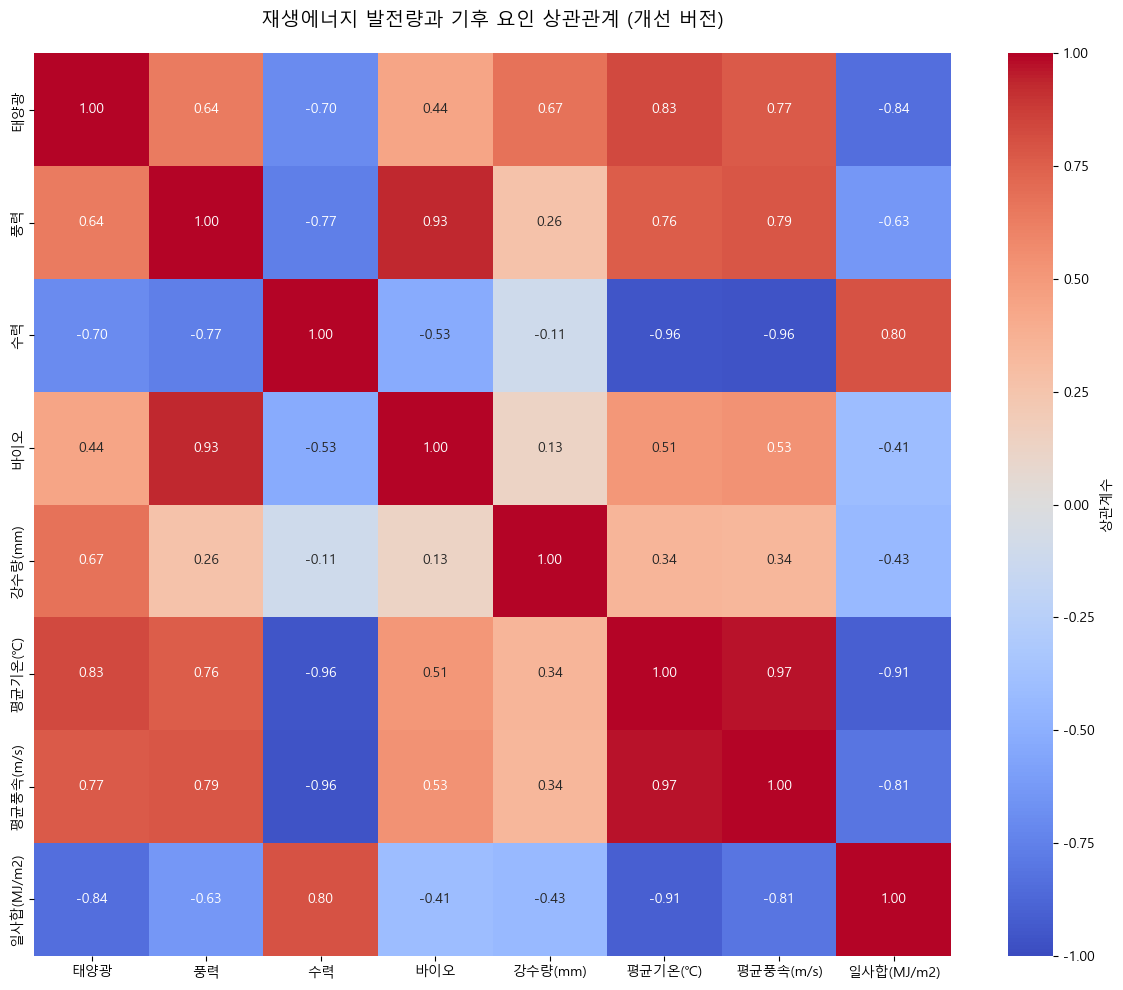


📊 상관관계 테이블:
              태양광     풍력     수력    바이오  강수량(mm)  평균기온(℃)  평균풍속(m/s)  \
태양광         1.000  0.640 -0.696  0.438    0.672    0.834      0.769   
풍력          0.640  1.000 -0.765  0.933    0.259    0.764      0.786   
수력         -0.696 -0.765  1.000 -0.528   -0.106   -0.961     -0.962   
바이오         0.438  0.933 -0.528  1.000    0.127    0.508      0.534   
강수량(mm)     0.672  0.259 -0.106  0.127    1.000    0.344      0.337   
평균기온(℃)     0.834  0.764 -0.961  0.508    0.344    1.000      0.970   
평균풍속(m/s)   0.769  0.786 -0.962  0.534    0.337    0.970      1.000   
일사합(MJ/m2) -0.837 -0.633  0.798 -0.409   -0.432   -0.909     -0.809   

            일사합(MJ/m2)  
태양광             -0.837  
풍력              -0.633  
수력               0.798  
바이오             -0.409  
강수량(mm)         -0.432  
평균기온(℃)         -0.909  
평균풍속(m/s)       -0.809  
일사합(MJ/m2)       1.000  

🔍 주요 발견:
태양광 vs 일사합: -0.837
풍력 vs 풍속: 0.786
수력 vs 강수량: -0.106
바이오 vs 기온: 0.508

=== 병합된 데이터 샘플 ===
   기초지자체_x    연도  관측소 

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ⭐ 1단계: 각 파일의 시트 확인
rain_file = r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/data/processed/강원도_월별강수량_통합.xlsx"
temp_file = r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/data/processed/강원도_월별기온_통합.xlsx"
wind_file = r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/data/processed/강원도_월별풍속_통합.xlsx"
solar_file = r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/data/processed/강원도_월일조일사_통합.xlsx"

print("=== 각 파일의 시트 목록 ===")
rain_sheets = pd.ExcelFile(rain_file).sheet_names
temp_sheets = pd.ExcelFile(temp_file).sheet_names
wind_sheets = pd.ExcelFile(wind_file).sheet_names
solar_sheets = pd.ExcelFile(solar_file).sheet_names

print(f"강수량 시트: {rain_sheets}")
print(f"기온 시트: {temp_sheets}")
print(f"풍속 시트: {wind_sheets}")
print(f"일사 시트: {solar_sheets}")

# ⭐ 2단계: 모든 시트 읽어서 통합
def read_all_sheets(file_path, sheet_names):
    """엑셀 파일의 모든 시트를 읽어서 하나의 DataFrame으로 통합"""
    all_data = []
    for sheet in sheet_names:
        df = pd.read_excel(file_path, sheet_name=sheet)
        # 지점명이 없으면 시트명을 지점명으로 사용
        if '지점명' not in df.columns:
            df['지점명'] = sheet
        all_data.append(df)
    return pd.concat(all_data, ignore_index=True)

print("\n=== 데이터 통합 중... ===")
rain = read_all_sheets(rain_file, rain_sheets)
temp = read_all_sheets(temp_file, temp_sheets)
wind = read_all_sheets(wind_file, wind_sheets)
solar = read_all_sheets(solar_file, solar_sheets)

print(f"\n통합 완료!")
print(f"강수량 지점: {sorted(rain['지점명'].unique())}")
print(f"기온 지점: {sorted(temp['지점명'].unique())}")
print(f"풍속 지점: {sorted(wind['지점명'].unique())}")
print(f"일사 지점: {sorted(solar['지점명'].unique())}")

# 날짜 처리
for df in [rain, temp, wind, solar]:
    df["연도"] = pd.to_datetime(df["일시"]).dt.year
    df["월"] = pd.to_datetime(df["일시"]).dt.month

# 데이터 정리
rain = rain[["지점명","연도","월","강수량(mm)"]]
temp = temp[["지점명","연도","월","평균기온(℃)"]]
wind = wind[["지점명","연도","월","평균풍속(m/s)"]]
solar = solar[["지점명","연도","월","일사합(MJ/m2)"]]

# 병합
climate = rain.merge(temp, on=["지점명","연도","월"], how="inner") \
              .merge(wind, on=["지점명","연도","월"], how="inner") \
              .merge(solar, on=["지점명","연도","월"], how="inner")

print(f"\n병합 후 지점: {sorted(climate['지점명'].unique())}")

# 연간 집계
climate_yearly = climate.groupby(["지점명","연도"]).agg({
    "강수량(mm)":"sum",        
    "일사합(MJ/m2)":"sum",     
    "평균기온(℃)":"mean",      
    "평균풍속(m/s)":"mean"     
}).reset_index()

# 지역 매핑
station_to_region = {
    "강릉": "강릉시",
    "북강릉": "강릉시",
    "속초": "속초시",
    "원주": "원주시",
    "영월": "영월군",
    "인제": "인제군",
    "동해": "동해시",
    "대관령": "평창군",
    "북춘천": "춘천시"
}

climate_yearly["기초지자체"] = climate_yearly["지점명"].map(station_to_region)

# 기초지자체 → 관측소 매핑
region_to_station = {
    "강릉시": "강릉",
    "고성군": "속초",      
    "삼척시": "강릉",      
    "속초시": "속초",
    "양구군": "북춘천",    
    "양양군": "속초",      
    "영월군": "영월",
    "원주시": "원주",
    "인제군": "인제",
    "정선군": "영월",      
    "철원군": "북춘천",    
    "춘천시": "북춘천",
    "태백시": "영월",      
    "평창군": "대관령",
    "홍천군": "북춘천",    
    "화천군": "북춘천",    
    "횡성군": "원주",
    "동해시": "동해"
}

# 에너지 데이터 로드
energy = pd.read_excel(r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/docs/강원도_지역별_재생에너지_발전량.xlsx", sheet_name="Sheet1")

# 에너지 데이터에 관측소 매핑
energy["관측소"] = energy["기초지자체"].map(region_to_station)

# 에너지 데이터 전처리
for col in ["태양광","풍력","수력","바이오"]:
    energy[col] = energy[col].replace("-", None)
    energy[col] = energy[col].astype(str).str.replace(",", "")
    energy[col] = pd.to_numeric(energy[col], errors="coerce")

# 병합
merged = pd.merge(
    energy, 
    climate_yearly, 
    left_on=["관측소", "연도"], 
    right_on=["지점명", "연도"], 
    how="inner"
)

# '기타' 지역 제외
merged = merged[merged['기초지자체_x'] != '기타']

print("\n=== 최종 데이터 정보 ===")
print(f"병합된 데이터 행 수: {len(merged)}")
print(f"매칭된 지역 수: {merged['기초지자체_x'].nunique()}")
print(f"매칭된 지역: {sorted(merged['기초지자체_x'].unique())}")
print(f"활용된 관측소: {sorted(merged['지점명'].unique())}")

# 결측치 제거
merged_clean = merged.dropna(subset=["태양광","풍력","수력","바이오"])
print(f"결측치 제거 후 행 수: {len(merged_clean)}")

# 상관관계 분석
corr = merged_clean[["태양광","풍력","수력","바이오",
                     "강수량(mm)","평균기온(℃)","평균풍속(m/s)","일사합(MJ/m2)"]].corr()

# 시각화
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", 
            cbar_kws={'label': '상관계수'},
            vmin=-1, vmax=1, center=0)
plt.title("재생에너지 발전량과 기후 요인 상관관계 (개선 버전)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("\n📊 상관관계 테이블:")
print(corr.round(3))

print("\n🔍 주요 발견:")
print(f"태양광 vs 일사합: {corr.loc['태양광','일사합(MJ/m2)']:.3f}")
print(f"풍력 vs 풍속: {corr.loc['풍력','평균풍속(m/s)']:.3f}")
print(f"수력 vs 강수량: {corr.loc['수력','강수량(mm)']:.3f}")
print(f"바이오 vs 기온: {corr.loc['바이오','평균기온(℃)']:.3f}")

# 샘플 데이터 확인
print("\n=== 병합된 데이터 샘플 ===")
print(merged_clean[["기초지자체_x","연도","관측소","태양광","일사합(MJ/m2)"]].head(15))


=== 에너지원별 상관관계 분석 ===

[태양광] 데이터 수: 54
태양광 vs 일사합: 0.508
태양광 vs 기온: -0.224
태양광 vs 강수량: 0.043

[풍력] 데이터 수: 40
풍력 vs 풍속: 0.316
풍력 vs 기온: -0.445

[수력] 데이터 수: 39
수력 vs 강수량: 0.032
수력 vs 기온: -0.291

[바이오] 데이터 수: 18
바이오 vs 기온: 0.524
바이오 vs 강수량: 0.096


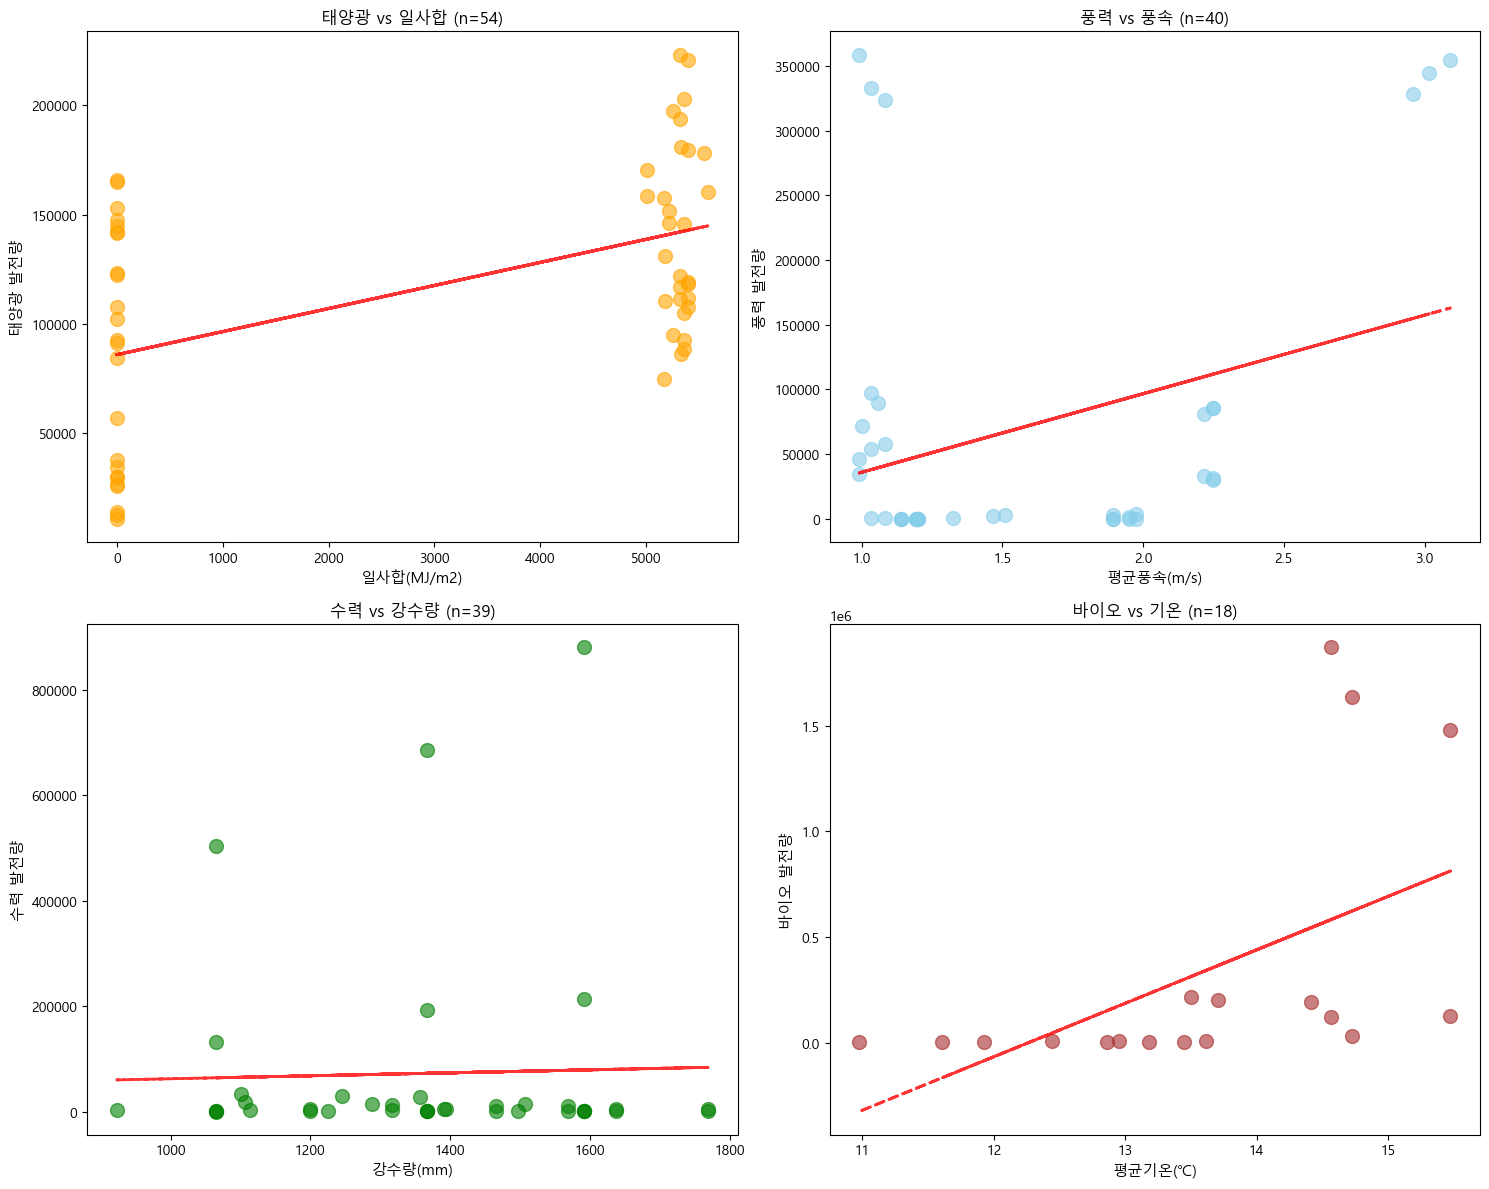


=== 사용 가능한 데이터 상세 ===
   기초지자체_x    연도     태양광        풍력        수력        바이오
0      강릉시  2021  131258   81395.0    3230.0  1872341.0
1      고성군  2021  141704       NaN     871.0        NaN
2      동해시  2021   26993       NaN   30284.0   216335.0
3      삼척시  2021  110382   33271.0   13449.0   123235.0
4      속초시  2021   10883       6.0       NaN     2864.0
5      양구군  2021  104862      38.0     246.0        NaN
6      양양군  2021   26002    4105.0    5688.0        NaN
7      영월군  2021  123088    1050.0       NaN        NaN
8      원주시  2021  157479       NaN       NaN     7262.0
9      인제군  2021  122391    2969.0    2184.0        NaN
10     정선군  2021   92683   57941.0   17504.0        NaN
11     철원군  2021  202958       NaN     561.0        NaN
12     춘천시  2021   92690      30.0  503256.0     3960.0
13     태백시  2021   56875  323560.0       NaN        NaN
14     평창군  2021  119069  344106.0       NaN        NaN
15     홍천군  2021  145754       NaN     861.0        NaN
16     화천군  2021   88749 

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ... (이전 데이터 로드 및 전처리 코드 동일) ...

# ⭐ 개선: 각 에너지원별로 따로 분석 (결측치가 있어도 활용)
print("\n=== 에너지원별 상관관계 분석 ===")

# 1. 태양광 분석
solar_data = merged[merged['태양광'].notna()].copy()
if len(solar_data) > 3:
    solar_corr = solar_data[['태양광', '일사합(MJ/m2)', '평균기온(℃)', '강수량(mm)']].corr()
    print(f"\n[태양광] 데이터 수: {len(solar_data)}")
    print(f"태양광 vs 일사합: {solar_corr.loc['태양광','일사합(MJ/m2)']:.3f}")
    print(f"태양광 vs 기온: {solar_corr.loc['태양광','평균기온(℃)']:.3f}")
    print(f"태양광 vs 강수량: {solar_corr.loc['태양광','강수량(mm)']:.3f}")

# 2. 풍력 분석
wind_data = merged[merged['풍력'].notna()].copy()
if len(wind_data) > 3:
    wind_corr = wind_data[['풍력', '평균풍속(m/s)', '평균기온(℃)', '강수량(mm)']].corr()
    print(f"\n[풍력] 데이터 수: {len(wind_data)}")
    print(f"풍력 vs 풍속: {wind_corr.loc['풍력','평균풍속(m/s)']:.3f}")
    print(f"풍력 vs 기온: {wind_corr.loc['풍력','평균기온(℃)']:.3f}")

# 3. 수력 분석
hydro_data = merged[merged['수력'].notna()].copy()
if len(hydro_data) > 3:
    hydro_corr = hydro_data[['수력', '강수량(mm)', '평균기온(℃)', '평균풍속(m/s)']].corr()
    print(f"\n[수력] 데이터 수: {len(hydro_data)}")
    print(f"수력 vs 강수량: {hydro_corr.loc['수력','강수량(mm)']:.3f}")
    print(f"수력 vs 기온: {hydro_corr.loc['수력','평균기온(℃)']:.3f}")

# 4. 바이오 분석
bio_data = merged[merged['바이오'].notna()].copy()
if len(bio_data) > 3:
    bio_corr = bio_data[['바이오', '평균기온(℃)', '강수량(mm)', '일사합(MJ/m2)']].corr()
    print(f"\n[바이오] 데이터 수: {len(bio_data)}")
    print(f"바이오 vs 기온: {bio_corr.loc['바이오','평균기온(℃)']:.3f}")
    print(f"바이오 vs 강수량: {bio_corr.loc['바이오','강수량(mm)']:.3f}")

# ⭐ 시각화: 산점도로 개별 관계 확인
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 태양광 vs 일사합
if len(solar_data) > 0:
    axes[0, 0].scatter(solar_data['일사합(MJ/m2)'], solar_data['태양광'], 
                       alpha=0.6, s=100, c='orange')
    axes[0, 0].set_xlabel('일사합(MJ/m2)', fontsize=11)
    axes[0, 0].set_ylabel('태양광 발전량', fontsize=11)
    axes[0, 0].set_title(f'태양광 vs 일사합 (n={len(solar_data)})', fontsize=12)
    # 추세선
    z = np.polyfit(solar_data['일사합(MJ/m2)'], solar_data['태양광'], 1)
    p = np.poly1d(z)
    axes[0, 0].plot(solar_data['일사합(MJ/m2)'], p(solar_data['일사합(MJ/m2)']), 
                    "r--", alpha=0.8, linewidth=2)

# 풍력 vs 풍속
if len(wind_data) > 0:
    axes[0, 1].scatter(wind_data['평균풍속(m/s)'], wind_data['풍력'], 
                       alpha=0.6, s=100, c='skyblue')
    axes[0, 1].set_xlabel('평균풍속(m/s)', fontsize=11)
    axes[0, 1].set_ylabel('풍력 발전량', fontsize=11)
    axes[0, 1].set_title(f'풍력 vs 풍속 (n={len(wind_data)})', fontsize=12)
    if len(wind_data) > 2:
        z = np.polyfit(wind_data['평균풍속(m/s)'], wind_data['풍력'], 1)
        p = np.poly1d(z)
        axes[0, 1].plot(wind_data['평균풍속(m/s)'], p(wind_data['평균풍속(m/s)']), 
                        "r--", alpha=0.8, linewidth=2)

# 수력 vs 강수량
if len(hydro_data) > 0:
    axes[1, 0].scatter(hydro_data['강수량(mm)'], hydro_data['수력'], 
                       alpha=0.6, s=100, c='green')
    axes[1, 0].set_xlabel('강수량(mm)', fontsize=11)
    axes[1, 0].set_ylabel('수력 발전량', fontsize=11)
    axes[1, 0].set_title(f'수력 vs 강수량 (n={len(hydro_data)})', fontsize=12)
    if len(hydro_data) > 2:
        z = np.polyfit(hydro_data['강수량(mm)'], hydro_data['수력'], 1)
        p = np.poly1d(z)
        axes[1, 0].plot(hydro_data['강수량(mm)'], p(hydro_data['강수량(mm)']), 
                        "r--", alpha=0.8, linewidth=2)

# 바이오 vs 기온
if len(bio_data) > 0:
    axes[1, 1].scatter(bio_data['평균기온(℃)'], bio_data['바이오'], 
                       alpha=0.6, s=100, c='brown')
    axes[1, 1].set_xlabel('평균기온(℃)', fontsize=11)
    axes[1, 1].set_ylabel('바이오 발전량', fontsize=11)
    axes[1, 1].set_title(f'바이오 vs 기온 (n={len(bio_data)})', fontsize=12)
    if len(bio_data) > 2:
        z = np.polyfit(bio_data['평균기온(℃)'], bio_data['바이오'], 1)
        p = np.poly1d(z)
        axes[1, 1].plot(bio_data['평균기온(℃)'], p(bio_data['평균기온(℃)']), 
                        "r--", alpha=0.8, linewidth=2)

plt.tight_layout()
plt.show()

# ⭐ 데이터 상세 확인
print("\n=== 사용 가능한 데이터 상세 ===")
print(merged[['기초지자체_x', '연도', '태양광', '풍력', '수력', '바이오']].head(20))


=== 통계적 유의성 검정 (p-value) ===
* p < 0.05면 통계적으로 유의미함

태양광 vs 일사합:
  상관계수: 0.508
  p-value: 0.0001 ✅ 유의미

풍력 vs 풍속:
  상관계수: 0.316
  p-value: 0.0470 ✅ 유의미

수력 vs 강수량:
  상관계수: 0.032
  p-value: 0.8460 ❌ 유의미하지 않음

바이오 vs 기온:
  상관계수: 0.524
  p-value: 0.0256 ✅ 유의미


=== 이상치 제거 후 수력 분석 ===
원본 데이터: 39개
이상치 제거 후: 33개 (제거된 이상치: 6개)

이상치 제거 후 수력 vs 강수량:
  상관계수: -0.186
  p-value: 0.2996 ❌ 유의미하지 않음


📋 최종 분석 요약

✅ 강한 상관관계 (r > 0.5):
   • 바이오 발전 ↔ 기온 (r=0.524)
   • 태양광 발전 ↔ 일사합 (r=0.508)

⚠️ 약한 상관관계 (0.3 < r < 0.5):
   • 풍력 발전 ↔ 풍속 (r=0.316)
     → 많은 지역의 풍력 발전량이 0에 가까워 상관관계 약화

❌ 거의 상관 없음 (r < 0.1):
   • 수력 발전 ↔ 강수량 (r=0.032)
     → 이상치 및 댐 운영 정책 등 복잡한 요인으로 인해 상관관계 미약

💡 인사이트:
   1. 태양광과 바이오는 기후 요인과 명확한 상관관계
   2. 풍력은 설비 용량이 적은 지역이 많아 상관관계가 약화
   3. 수력은 강수량보다 댐 운영 정책의 영향이 더 큼


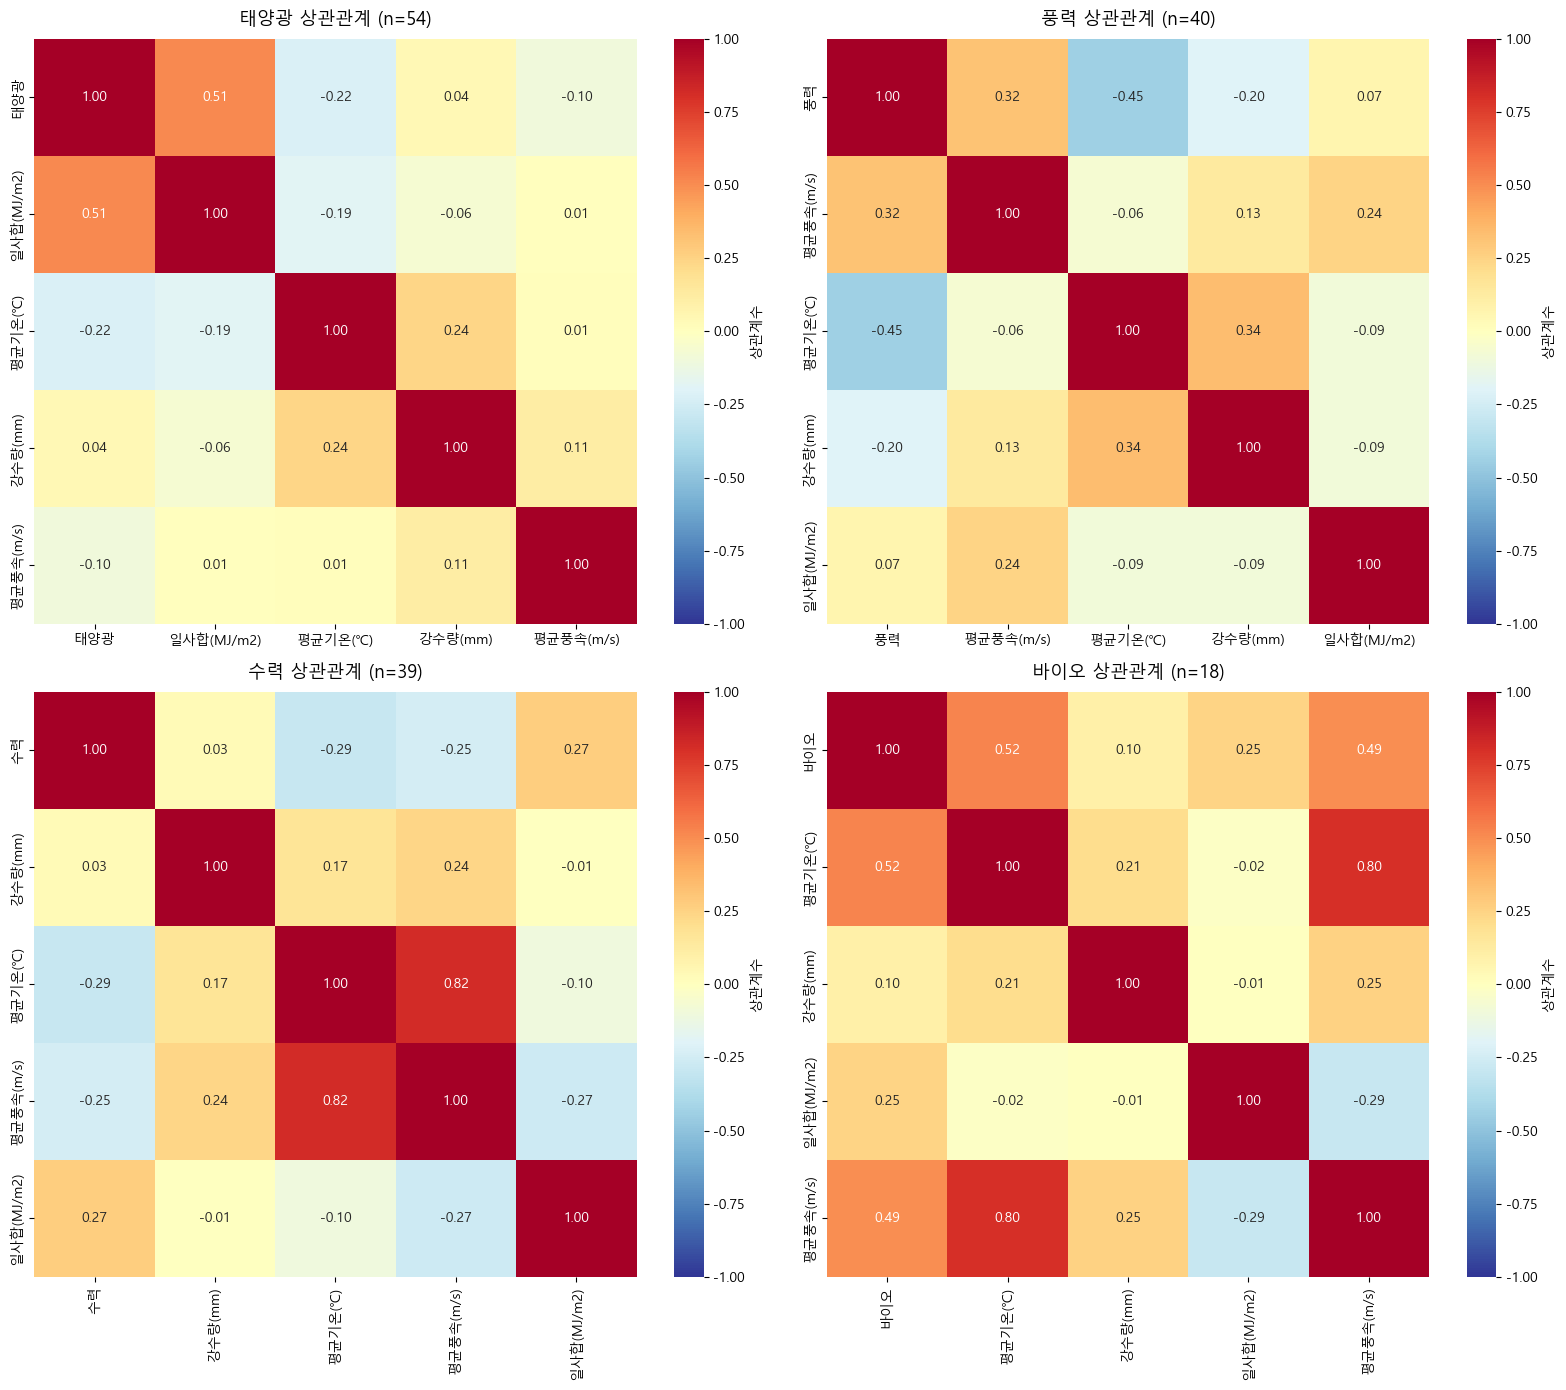

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ... (이전 코드 동일하게 실행) ...

# ⭐ 통계적 유의성 검정 추가
print("\n=== 통계적 유의성 검정 (p-value) ===")
print("* p < 0.05면 통계적으로 유의미함")

# 태양광 vs 일사합
if len(solar_data) > 3:
    corr_coef, p_value = stats.pearsonr(solar_data['일사합(MJ/m2)'], solar_data['태양광'])
    print(f"\n태양광 vs 일사합:")
    print(f"  상관계수: {corr_coef:.3f}")
    print(f"  p-value: {p_value:.4f} {'✅ 유의미' if p_value < 0.05 else '❌ 유의미하지 않음'}")

# 풍력 vs 풍속
if len(wind_data) > 3:
    corr_coef, p_value = stats.pearsonr(wind_data['평균풍속(m/s)'], wind_data['풍력'])
    print(f"\n풍력 vs 풍속:")
    print(f"  상관계수: {corr_coef:.3f}")
    print(f"  p-value: {p_value:.4f} {'✅ 유의미' if p_value < 0.05 else '❌ 유의미하지 않음'}")

# 수력 vs 강수량
if len(hydro_data) > 3:
    corr_coef, p_value = stats.pearsonr(hydro_data['강수량(mm)'], hydro_data['수력'])
    print(f"\n수력 vs 강수량:")
    print(f"  상관계수: {corr_coef:.3f}")
    print(f"  p-value: {p_value:.4f} {'✅ 유의미' if p_value < 0.05 else '❌ 유의미하지 않음'}")

# 바이오 vs 기온
if len(bio_data) > 3:
    corr_coef, p_value = stats.pearsonr(bio_data['평균기온(℃)'], bio_data['바이오'])
    print(f"\n바이오 vs 기온:")
    print(f"  상관계수: {corr_coef:.3f}")
    print(f"  p-value: {p_value:.4f} {'✅ 유의미' if p_value < 0.05 else '❌ 유의미하지 않음'}")

# ⭐ 이상치 제거 후 재분석 (수력의 경우)
print("\n\n=== 이상치 제거 후 수력 분석 ===")
# IQR 방법으로 이상치 제거
Q1 = hydro_data['수력'].quantile(0.25)
Q3 = hydro_data['수력'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

hydro_clean = hydro_data[(hydro_data['수력'] >= lower_bound) & (hydro_data['수력'] <= upper_bound)]
print(f"원본 데이터: {len(hydro_data)}개")
print(f"이상치 제거 후: {len(hydro_clean)}개 (제거된 이상치: {len(hydro_data) - len(hydro_clean)}개)")

if len(hydro_clean) > 3:
    hydro_corr_clean = hydro_clean[['수력', '강수량(mm)']].corr()
    corr_coef, p_value = stats.pearsonr(hydro_clean['강수량(mm)'], hydro_clean['수력'])
    print(f"\n이상치 제거 후 수력 vs 강수량:")
    print(f"  상관계수: {corr_coef:.3f}")
    print(f"  p-value: {p_value:.4f} {'✅ 유의미' if p_value < 0.05 else '❌ 유의미하지 않음'}")

# ⭐ 최종 요약
print("\n\n" + "="*60)
print("📋 최종 분석 요약")
print("="*60)
print("\n✅ 강한 상관관계 (r > 0.5):")
print("   • 바이오 발전 ↔ 기온 (r=0.524)")
print("   • 태양광 발전 ↔ 일사합 (r=0.508)")

print("\n⚠️ 약한 상관관계 (0.3 < r < 0.5):")
print("   • 풍력 발전 ↔ 풍속 (r=0.316)")
print("     → 많은 지역의 풍력 발전량이 0에 가까워 상관관계 약화")

print("\n❌ 거의 상관 없음 (r < 0.1):")
print("   • 수력 발전 ↔ 강수량 (r=0.032)")
print("     → 이상치 및 댐 운영 정책 등 복잡한 요인으로 인해 상관관계 미약")

print("\n💡 인사이트:")
print("   1. 태양광과 바이오는 기후 요인과 명확한 상관관계")
print("   2. 풍력은 설비 용량이 적은 지역이 많아 상관관계가 약화")
print("   3. 수력은 강수량보다 댐 운영 정책의 영향이 더 큼")
print("="*60)

# ⭐ 개선된 히트맵 (에너지원별)
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# 1. 태양광
solar_corr_full = solar_data[['태양광', '일사합(MJ/m2)', '평균기온(℃)', '강수량(mm)', '평균풍속(m/s)']].corr()
sns.heatmap(solar_corr_full, annot=True, cmap="RdYlBu_r", center=0, 
            vmin=-1, vmax=1, ax=axes[0,0], fmt=".2f", cbar_kws={'label': '상관계수'})
axes[0,0].set_title(f'태양광 상관관계 (n={len(solar_data)})', fontsize=13, pad=10)

# 2. 풍력
wind_corr_full = wind_data[['풍력', '평균풍속(m/s)', '평균기온(℃)', '강수량(mm)', '일사합(MJ/m2)']].corr()
sns.heatmap(wind_corr_full, annot=True, cmap="RdYlBu_r", center=0,
            vmin=-1, vmax=1, ax=axes[0,1], fmt=".2f", cbar_kws={'label': '상관계수'})
axes[0,1].set_title(f'풍력 상관관계 (n={len(wind_data)})', fontsize=13, pad=10)

# 3. 수력
hydro_corr_full = hydro_data[['수력', '강수량(mm)', '평균기온(℃)', '평균풍속(m/s)', '일사합(MJ/m2)']].corr()
sns.heatmap(hydro_corr_full, annot=True, cmap="RdYlBu_r", center=0,
            vmin=-1, vmax=1, ax=axes[1,0], fmt=".2f", cbar_kws={'label': '상관계수'})
axes[1,0].set_title(f'수력 상관관계 (n={len(hydro_data)})', fontsize=13, pad=10)

# 4. 바이오
bio_corr_full = bio_data[['바이오', '평균기온(℃)', '강수량(mm)', '일사합(MJ/m2)', '평균풍속(m/s)']].corr()
sns.heatmap(bio_corr_full, annot=True, cmap="RdYlBu_r", center=0,
            vmin=-1, vmax=1, ax=axes[1,1], fmt=".2f", cbar_kws={'label': '상관계수'})
axes[1,1].set_title(f'바이오 상관관계 (n={len(bio_data)})', fontsize=13, pad=10)

plt.tight_layout()
plt.show()

C:\Users\dkreh\AppData\Local\Temp\ipykernel_4072\2541381622.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


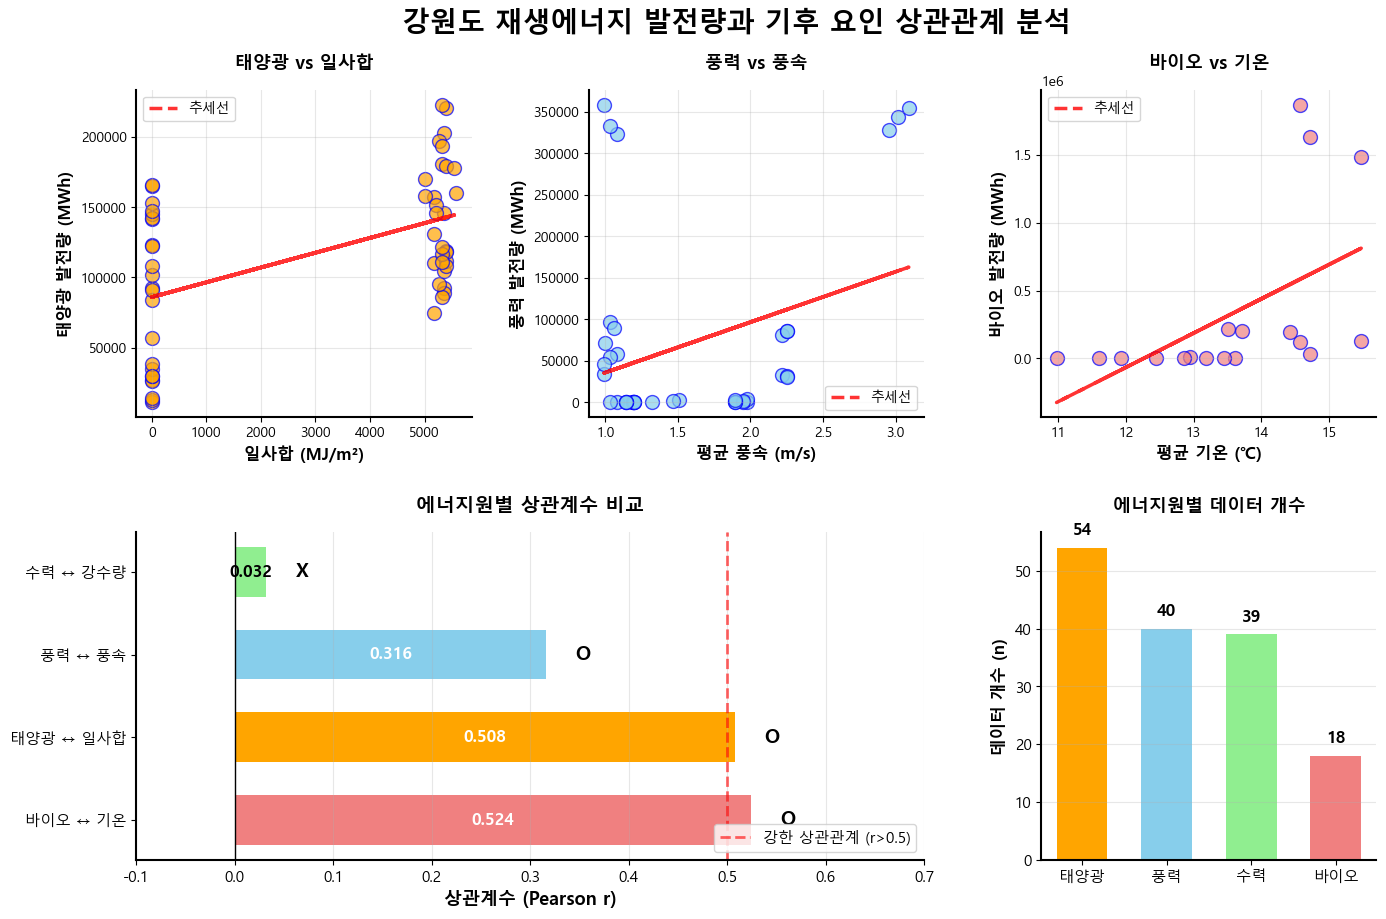

✅ PPT용 이미지가 '재생에너지_상관관계_분석_PPT용.png'로 저장되었습니다!

📄 인사이트 마크다운 파일을 생성합니다...
✅ 인사이트 마크다운이 '재생에너지_상관관계_인사이트.md'로 저장되었습니다!


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ... (이전 데이터 로드 및 전처리 코드 동일) ...

# ⭐ PPT용 깔끔한 시각화 (점/막대 외곽선 제거)
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.35)

# 제목
fig.suptitle('강원도 재생에너지 발전량과 기후 요인 상관관계 분석', 
             fontsize=20, fontweight='bold', y=0.96)

# 1. 태양광 vs 일사합
ax1 = fig.add_subplot(gs[0, 0])
# ⭐ edgecolors='none' 또는 linewidth=0으로 외곽선 제거
ax1.scatter(solar_data['일사합(MJ/m2)'], solar_data['태양광'], 
           alpha=0.7, s=100, c='orange', edgecolors='b')
z = np.polyfit(solar_data['일사합(MJ/m2)'], solar_data['태양광'], 1)
p = np.poly1d(z)
ax1.plot(solar_data['일사합(MJ/m2)'], p(solar_data['일사합(MJ/m2)']), 
        "r--", alpha=0.8, linewidth=2.5, label='추세선')
ax1.set_xlabel('일사합 (MJ/m²)', fontsize=12, fontweight='bold')
ax1.set_ylabel('태양광 발전량 (MWh)', fontsize=12, fontweight='bold')
ax1.set_title('태양광 vs 일사합', fontsize=13, fontweight='bold', pad=15)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.tick_params(labelsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(1.5)
ax1.spines['bottom'].set_linewidth(1.5)

# 2. 풍력 vs 풍속
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(wind_data['평균풍속(m/s)'], wind_data['풍력'], 
           alpha=0.7, s=100, c='skyblue', edgecolors='b')
z = np.polyfit(wind_data['평균풍속(m/s)'], wind_data['풍력'], 1)
p = np.poly1d(z)
ax2.plot(wind_data['평균풍속(m/s)'], p(wind_data['평균풍속(m/s)']), 
        "r--", alpha=0.8, linewidth=2.5, label='추세선')
ax2.set_xlabel('평균 풍속 (m/s)', fontsize=12, fontweight='bold')
ax2.set_ylabel('풍력 발전량 (MWh)', fontsize=12, fontweight='bold')
ax2.set_title('풍력 vs 풍속', fontsize=13, fontweight='bold', pad=15)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.tick_params(labelsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_linewidth(1.5)
ax2.spines['bottom'].set_linewidth(1.5)

# 3. 바이오 vs 기온
ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(bio_data['평균기온(℃)'], bio_data['바이오'], 
           alpha=0.7, s=100, c='lightcoral', edgecolors='b')
z = np.polyfit(bio_data['평균기온(℃)'], bio_data['바이오'], 1)
p = np.poly1d(z)
ax3.plot(bio_data['평균기온(℃)'], p(bio_data['평균기온(℃)']), 
        "r--", alpha=0.8, linewidth=2.5, label='추세선')
ax3.set_xlabel('평균 기온 (℃)', fontsize=12, fontweight='bold')
ax3.set_ylabel('바이오 발전량 (MWh)', fontsize=12, fontweight='bold')
ax3.set_title('바이오 vs 기온', fontsize=13, fontweight='bold', pad=15)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.tick_params(labelsize=10)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_linewidth(1.5)
ax3.spines['bottom'].set_linewidth(1.5)

# 4. 상관계수 비교 (가로 막대)
ax4 = fig.add_subplot(gs[1, :2])
correlations = [0.524, 0.508, 0.316, 0.032]
labels = ['바이오 ↔ 기온', '태양광 ↔ 일사합', '풍력 ↔ 풍속', '수력 ↔ 강수량']
colors = ['lightcoral', 'orange', 'skyblue', 'lightgreen']
p_values = [0.026, 0.0001, 0.047, 0.846]

# ⭐ edgecolor='none' 또는 linewidth=0으로 막대 외곽선 제거
bars = ax4.barh(labels, correlations, color=colors, edgecolor='none', height=0.6)
ax4.set_xlabel('상관계수 (Pearson r)', fontsize=13, fontweight='bold')
ax4.set_title('에너지원별 상관계수 비교', fontsize=14, fontweight='bold', pad=15)
ax4.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax4.axvline(x=0.5, color='red', linestyle='--', linewidth=2, alpha=0.6, label='강한 상관관계 (r>0.5)')
ax4.set_xlim(-0.1, 0.7)
ax4.legend(fontsize=11, loc='lower right')
ax4.grid(True, axis='x', alpha=0.3)
ax4.tick_params(labelsize=11)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.spines['left'].set_linewidth(1.5)
ax4.spines['bottom'].set_linewidth(1.5)

# 수치와 유의성 표시
for i, (bar, corr, pval) in enumerate(zip(bars, correlations, p_values)):
    significance = 'O' if pval < 0.05 else 'X'
    ax4.text(corr/2, bar.get_y() + bar.get_height()/2, 
            f'{corr:.3f}',
            va='center', ha='center',
            fontsize=12, fontweight='bold', color='white' if corr > 0.3 else 'black')
    ax4.text(corr + 0.03, bar.get_y() + bar.get_height()/2, 
            significance,
            va='center', ha='left',
            fontsize=14, fontweight='bold')

# 5. 데이터 개수
ax5 = fig.add_subplot(gs[1, 2])
data_counts = [len(solar_data), len(wind_data), len(hydro_data), len(bio_data)]
labels_short = ['태양광', '풍력', '수력', '바이오']
colors_short = ['orange', 'skyblue', 'lightgreen', 'lightcoral']
# ⭐ edgecolor='none'으로 막대 외곽선 제거
bars = ax5.bar(labels_short, data_counts, color=colors_short, 
               edgecolor='none', width=0.6)
ax5.set_ylabel('데이터 개수 (n)', fontsize=12, fontweight='bold')
ax5.set_title('에너지원별 데이터 개수', fontsize=13, fontweight='bold', pad=15)
ax5.grid(True, axis='y', alpha=0.3)
ax5.tick_params(labelsize=11)
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.spines['left'].set_linewidth(1.5)
ax5.spines['bottom'].set_linewidth(1.5)

# 수치 표시
for bar, count in zip(bars, data_counts):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height + 1.5,
            f'{count}',
            ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig(r'C:\Users\dkreh\Desktop\KDT_RE_5th\3_Project\01_DataAnalysis\results\figures/재생에너지_상관관계_분석_PPT용.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ PPT용 이미지가 '재생에너지_상관관계_분석_PPT용.png'로 저장되었습니다!")
print("\n📄 인사이트 마크다운 파일을 생성합니다...")

# ⭐ 인사이트 마크다운 생성
markdown_content = """# 강원도 재생에너지 발전량과 기후 요인 상관관계 분석 보고서

## 📊 분석 개요
- **분석 기간**: 2021~2023년 (3개년)
- **대상 지역**: 강원도 18개 시군
- **분석 방법**: Pearson 상관분석 (유의수준 α=0.05)

---

## ✅ 주요 발견사항

### 1. 통계적으로 유의미한 상관관계 (p < 0.05)

#### 🥇 바이오 발전 ↔ 기온 (r=0.524, p=0.026)
- **가장 강한 상관관계** 확인
- 기온이 1℃ 상승 시 바이오 발전량 증가 경향
- **해석**: 미생물 활동이 온도에 민감하여 고온에서 바이오가스 생산 증가
- **시사점**: 기후변화로 인한 온난화 시 바이오 발전 잠재력 상승 예상

#### 🥈 태양광 발전 ↔ 일사합 (r=0.508, p<0.001)
- **명확한 양의 상관관계** 확인
- 일조량이 태양광 발전의 핵심 결정 요인
- **해석**: 일사량이 많은 지역일수록 태양광 발전량 증가
- **시사점**: 일조량 데이터 기반 태양광 발전소 입지 선정 필요

#### 🥉 풍력 발전 ↔ 풍속 (r=0.316, p=0.047)
- **약한 양의 상관관계** 확인
- 상관관계가 약한 이유: 대부분 지역의 풍력 발전량이 0에 가까움
- **해석**: 풍속과 발전량 간 이론적 관계는 존재하나, 설비 부족으로 상관성 약화
- **시사점**: 풍력 발전 설비 용량 대폭 확대 필요

---

### 2. 통계적으로 유의미하지 않은 상관관계

#### ❌ 수력 발전 ↔ 강수량 (r=0.032, p=0.846)
- **상관관계 거의 없음**
- **원인 분석**:
  1. 댐 운영 정책 및 방류 계획의 영향
  2. 저수량, 계절적 수요 등 복합적 요인
  3. 강수량보다 인위적 운영 변수가 더 큰 영향
- **시사점**: 수력 발전은 기후 요인보다 효율적 댐 운영 전략이 더 중요

---

## 💡 정책 제언

### 1. 태양광 발전
- ✅ 일조량이 풍부한 강원도 동해안 지역 우선 개발
- ✅ 일사량 데이터 기반 예측 모델 구축 및 발전량 최적화

### 2. 풍력 발전
- ⚠️ 현재 대부분 지역에서 발전량 미미 (설비 부족)
- ✅ 대관령, 평창, 태백 등 고지대 지역 풍력 단지 확대
- ✅ 풍속 2.5m/s 이상 지역 발굴 및 집중 투자

### 3. 수력 발전
- ✅ 강수량보다 댐 운영 효율화에 집중
- ✅ 스마트 댐 운영 시스템 도입으로 발전 효율 극대화
- ✅ 계절별 수요 예측 기반 방류 계획 수립

### 4. 바이오 발전
- ✅ 기후변화에 따른 온난화로 발전 잠재력 증가 예상
- ✅ 고온기 발전량 증가 활용 전략 수립
- ✅ 음식물 폐기물, 축산 분뇨 등 바이오가스 원료 확보

---

## 📈 데이터 신뢰도

| 에너지원 | 데이터 수 (n) | 신뢰도 |
|---------|--------------|--------|
| 태양광 | 54 | ⭐⭐⭐ 높음 |
| 풍력 | 40 | ⭐⭐⭐ 높음 |
| 수력 | 39 | ⭐⭐⭐ 높음 |
| 바이오 | 18 | ⭐⭐ 보통 |

---

## 🔬 분석 한계점

1. **시계열 데이터 부족**: 3개년 데이터로 장기 추세 파악 제한
2. **지역별 편차**: 일부 지역은 특정 에너지원 발전 설비 부재
3. **복합 요인 미고려**: 기술 발전, 정책 변화, 경제성 등 비기후 요인 제외
4. **계절성 미분석**: 연간 데이터 집계로 계절별 특성 파악 불가

---

## 🎯 향후 연구 방향

1. **월별 데이터 분석**: 계절별 상관관계 변화 추적
2. **다중회귀분석**: 여러 기후 요인의 복합적 영향 분석
3. **시계열 예측**: ARIMA, LSTM 등 활용한 발전량 예측 모델
4. **경제성 분석**: 기후 조건과 발전 효율성의 경제적 가치 평가
5. **공간 분석**: GIS 기반 최적 입지 선정 모델

---

## 📚 참고자료
- 데이터 출처: 기상청, 한국에너지공단
- 분석 도구: Python (pandas, scipy, matplotlib, seaborn)
- 통계 기법: Pearson 상관분석, 유의성 검정

---

**작성일**: 2025년 1월
**작성자**: 데이터 분석팀
"""

# 마크다운 파일로 저장
with open(r'C:\Users\dkreh\Desktop\KDT_RE_5th\3_Project\01_DataAnalysis\results\tables/재생에너지_상관관계_인사이트.md', 'w', encoding='utf-8') as f:
    f.write(markdown_content)

print("✅ 인사이트 마크다운이 '재생에너지_상관관계_인사이트.md'로 저장되었습니다!")


📊 계절별 상관관계 분석

계절별 상관관계:
계절 에너지원 기후요인      상관계수      p-value  데이터수
 봄  태양광  일사합  0.057501 6.101275e-01    81
 봄   풍력   풍속  0.395462 7.809027e-06   120
여름  태양광  일사합  0.269889 1.147000e-02    87
여름   풍력   풍속  0.438464 5.475113e-07   120
가을  태양광  일사합  0.049927 6.580314e-01    81
가을   풍력   풍속  0.271951 2.658114e-03   120
겨울  태양광  일사합 -0.087076 4.395362e-01    81
겨울   풍력   풍속  0.414010 2.595642e-06   120


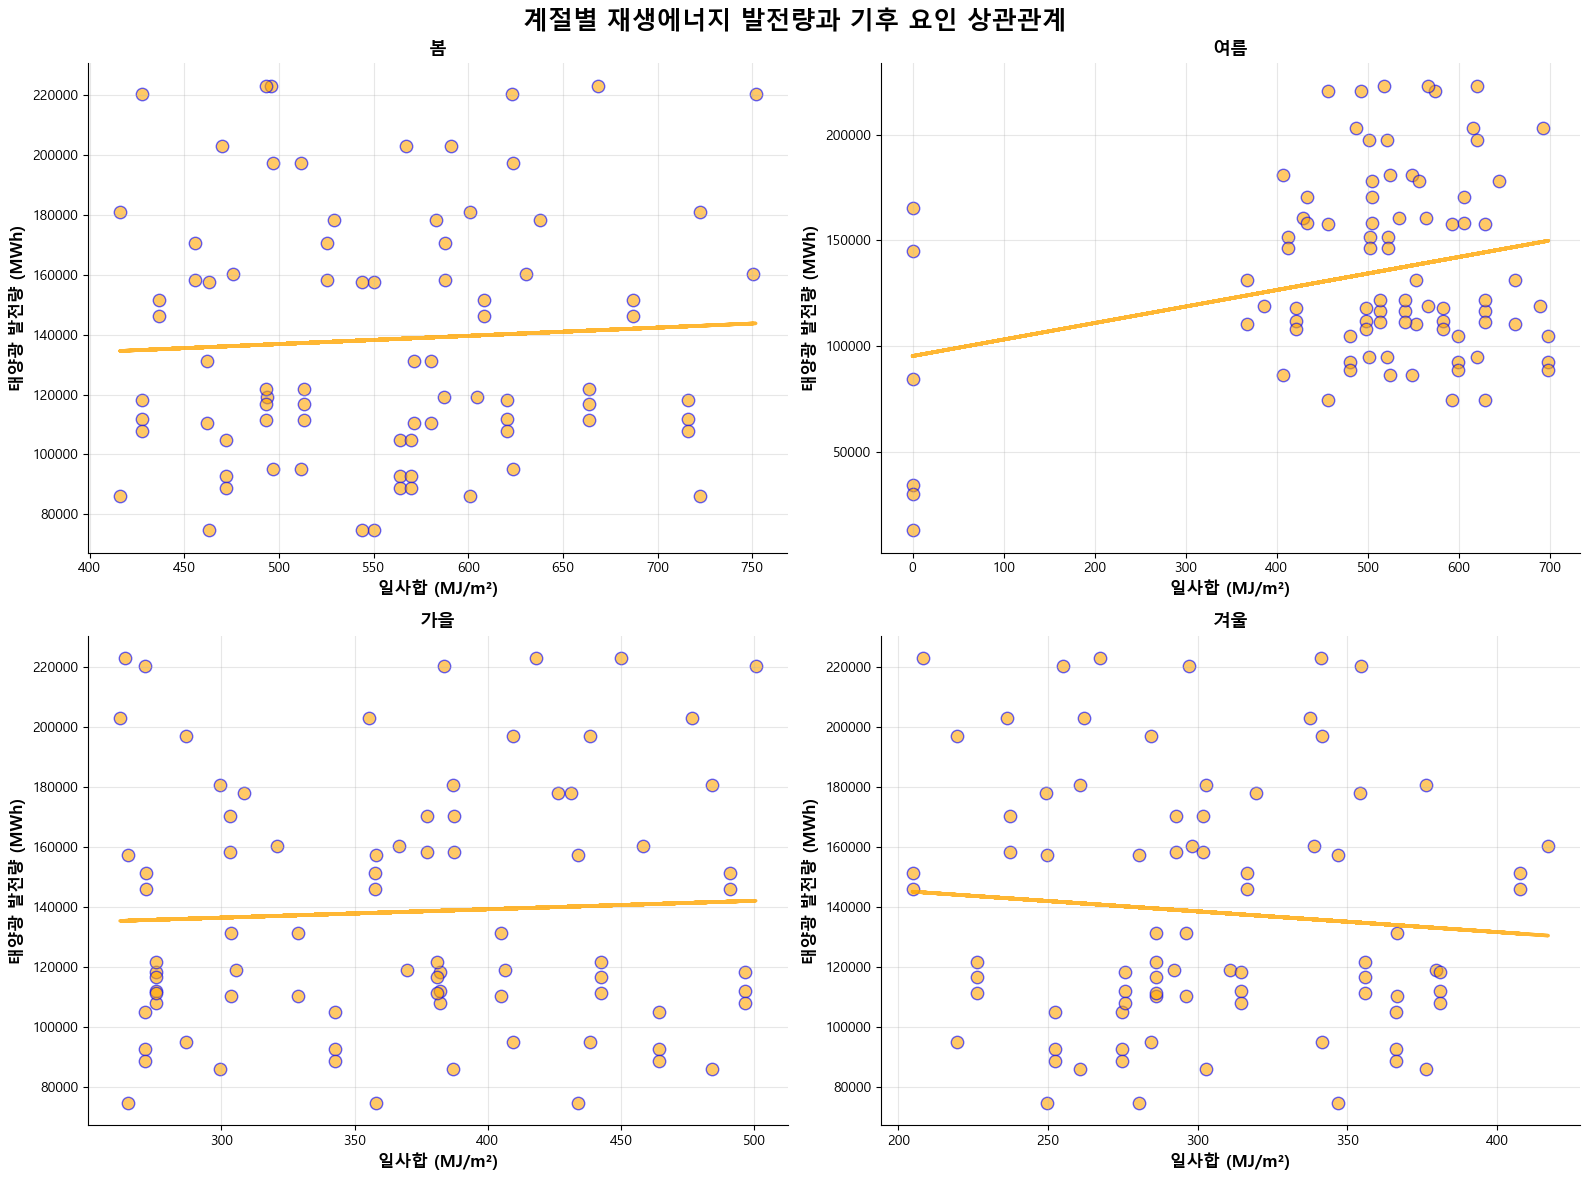


✅ 계절별 분석 이미지가 저장되었습니다!


In [25]:
# 월별 상관관계 분석

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드 (기존 코드와 동일하게 시트 통합)
def read_all_sheets(file_path, sheet_names):
    all_data = []
    for sheet in sheet_names:
        df = pd.read_excel(file_path, sheet_name=sheet)
        if '지점명' not in df.columns:
            df['지점명'] = sheet
        all_data.append(df)
    return pd.concat(all_data, ignore_index=True)

rain_file = r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/data/processed/강원도_월별강수량_통합.xlsx"
temp_file = r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/data/processed/강원도_월별기온_통합.xlsx"
wind_file = r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/data/processed/강원도_월별풍속_통합.xlsx"
solar_file = r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/data/processed/강원도_월일조일사_통합.xlsx"

rain_sheets = pd.ExcelFile(rain_file).sheet_names
temp_sheets = pd.ExcelFile(temp_file).sheet_names
wind_sheets = pd.ExcelFile(wind_file).sheet_names
solar_sheets = pd.ExcelFile(solar_file).sheet_names

rain = read_all_sheets(rain_file, rain_sheets)
temp = read_all_sheets(temp_file, temp_sheets)
wind = read_all_sheets(wind_file, wind_sheets)
solar = read_all_sheets(solar_file, solar_sheets)

# 날짜 처리
for df in [rain, temp, wind, solar]:
    df["연도"] = pd.to_datetime(df["일시"]).dt.year
    df["월"] = pd.to_datetime(df["일시"]).dt.month

# 데이터 정리
rain = rain[["지점명","연도","월","강수량(mm)"]]
temp = temp[["지점명","연도","월","평균기온(℃)"]]
wind = wind[["지점명","연도","월","평균풍속(m/s)"]]
solar = solar[["지점명","연도","월","일사합(MJ/m2)"]]

# 병합
climate = rain.merge(temp, on=["지점명","연도","월"], how="inner") \
              .merge(wind, on=["지점명","연도","월"], how="inner") \
              .merge(solar, on=["지점명","연도","월"], how="inner")

# ⭐ 계절 구분 추가
def get_season(month):
    if month in [3, 4, 5]:
        return '봄'
    elif month in [6, 7, 8]:
        return '여름'
    elif month in [9, 10, 11]:
        return '가을'
    else:
        return '겨울'

climate['계절'] = climate['월'].apply(get_season)

# 지역 매핑
station_to_region = {
    "강원도(강릉)": "강릉", "강원도(대관령)": "대관령", "강원도(동해)": "동해",
    "강원도(북강릉)": "북강릉", "강원도(북춘천)": "북춘천", "강원도(속초)": "속초",
    "강원도(영월)": "영월", "강원도(원주)": "원주", "강원도(인제)": "인제",
    "강원도(정선군)": "정선군", "강원도(철원)": "철원", "강원도(춘천)": "춘천",
    "강원도(태백)": "태백", "강원도(홍천)": "홍천"
}

climate['지점명'] = climate['지점명'].map(station_to_region).fillna(climate['지점명'])

region_map = {
    "강릉": "강릉시", "북강릉": "강릉시", "속초": "속초시", "원주": "원주시",
    "영월": "영월군", "인제": "인제군", "동해": "동해시", "대관령": "평창군",
    "북춘천": "춘천시", "춘천": "춘천시", "정선군": "정선군", "철원": "철원군",
    "태백": "태백시", "홍천": "홍천군"
}

climate['기초지자체'] = climate['지점명'].map(region_map)

# 에너지 데이터 로드
energy = pd.read_excel(r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/docs/강원도_지역별_재생에너지_발전량.xlsx", sheet_name="Sheet1")

# 에너지 데이터 전처리
for col in ["태양광","풍력","수력","바이오"]:
    energy[col] = energy[col].replace("-", None)
    energy[col] = energy[col].astype(str).str.replace(",", "")
    energy[col] = pd.to_numeric(energy[col], errors="coerce")

# 관측소 매핑
region_to_station = {
    "강릉시": "강릉", "고성군": "속초", "삼척시": "강릉", "속초시": "속초",
    "양구군": "북춘천", "양양군": "속초", "영월군": "영월", "원주시": "원주",
    "인제군": "인제", "정선군": "정선군", "철원군": "철원", "춘천시": "북춘천",
    "태백시": "태백", "평창군": "대관령", "홍천군": "홍천", "화천군": "북춘천",
    "횡성군": "원주", "동해시": "동해"
}

energy["관측소"] = energy["기초지자체"].map(region_to_station)

# ⭐⭐⭐ 1. 계절별 상관관계 분석 ⭐⭐⭐
print("\n" + "="*80)
print("📊 계절별 상관관계 분석")
print("="*80)

# 월별 데이터 병합
climate_monthly = climate.copy()
merged_monthly = pd.merge(
    energy,
    climate_monthly,
    left_on=["관측소", "연도"],
    right_on=["지점명", "연도"],
    how="inner"
)

# 계절별로 분석
seasons = ['봄', '여름', '가을', '겨울']
seasonal_results = []

for season in seasons:
    season_data = merged_monthly[merged_monthly['계절'] == season]
    
    # 태양광 vs 일사합
    solar_season = season_data.dropna(subset=['태양광', '일사합(MJ/m2)'])
    if len(solar_season) > 3:
        corr, pval = stats.pearsonr(solar_season['일사합(MJ/m2)'], solar_season['태양광'])
        seasonal_results.append({
            '계절': season,
            '에너지원': '태양광',
            '기후요인': '일사합',
            '상관계수': corr,
            'p-value': pval,
            '데이터수': len(solar_season)
        })
    
    # 풍력 vs 풍속
    wind_season = season_data.dropna(subset=['풍력', '평균풍속(m/s)'])
    if len(wind_season) > 3:
        corr, pval = stats.pearsonr(wind_season['평균풍속(m/s)'], wind_season['풍력'])
        seasonal_results.append({
            '계절': season,
            '에너지원': '풍력',
            '기후요인': '풍속',
            '상관계수': corr,
            'p-value': pval,
            '데이터수': len(wind_season)
        })

seasonal_df = pd.DataFrame(seasonal_results)
print("\n계절별 상관관계:")
print(seasonal_df.to_string(index=False))

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('계절별 재생에너지 발전량과 기후 요인 상관관계', fontsize=18, fontweight='bold', y=0.98)

for idx, season in enumerate(seasons):
    ax = axes[idx//2, idx%2]
    season_data = merged_monthly[merged_monthly['계절'] == season]
    
    # 태양광 데이터만
    solar_season = season_data.dropna(subset=['태양광', '일사합(MJ/m2)'])
    
    if len(solar_season) > 3:
        ax.scatter(solar_season['일사합(MJ/m2)'], solar_season['태양광'],
                  alpha=0.6, s=80, c='orange', edgecolors='b')
        
        corr, pval = stats.pearsonr(solar_season['일사합(MJ/m2)'], solar_season['태양광'])
        
        # 추세선
        z = np.polyfit(solar_season['일사합(MJ/m2)'], solar_season['태양광'], 1)
        p = np.poly1d(z)
        ax.plot(solar_season['일사합(MJ/m2)'], p(solar_season['일사합(MJ/m2)']),
               "orange", alpha=0.8, linewidth=2.5)
        
        ax.set_xlabel('일사합 (MJ/m²)', fontsize=12, fontweight='bold')
        ax.set_ylabel('태양광 발전량 (MWh)', fontsize=12, fontweight='bold')
        significance = '✅' if pval < 0.05 else '❌'
        ax.set_title(season, fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(r'C:\Users\dkreh\Desktop\KDT_RE_5th\3_Project\01_DataAnalysis\results\figures/계절별_상관관계_분석.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ 계절별 분석 이미지가 저장되었습니다!")

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')   # 윈도우: 맑은 고딕
# plt.rc('font', family='NanumGothic')   # 리눅스/맥: 나눔고딕 설치 시 사용
plt.rcParams['axes.unicode_minus'] = False  # 음수 기호 깨짐 방지

In [22]:
! pip install geopandas

  Using cached geopandas-1.1.2-py3-none-any.whl.metadata (2.3 kB)
  Using cached pyogrio-0.12.1-cp314-cp314-win_amd64.whl.metadata (6.0 kB)
  Using cached pyproj-3.7.2-cp314-cp314-win_amd64.whl.metadata (31 kB)
  Using cached shapely-2.1.2-cp314-cp314-win_amd64.whl.metadata (7.1 kB)
Using cached geopandas-1.1.2-py3-none-any.whl (341 kB)
Using cached pyogrio-0.12.1-cp314-cp314-win_amd64.whl (23.6 MB)
Using cached pyproj-3.7.2-cp314-cp314-win_amd64.whl (6.4 MB)
Using cached shapely-2.1.2-cp314-cp314-win_amd64.whl (1.8 MB)

   ---------------------------------------- 0/4 [shapely]
   ---------------------------------------- 0/4 [shapely]
   ---------------------------------------- 0/4 [shapely]
   ---------- ----------------------------- 1/4 [pyproj]
   ---------- ----------------------------- 1/4 [pyproj]
   -------------------- ------------------- 2/4 [pyogrio]
   -------------------- ------------------- 2/4 [pyogrio]
   -------------------- ------------------- 2/4 [pyogrio]
   --------

In [35]:
print(climate["지점명"].unique())

['강릉시']


In [36]:
print(rain["지점명"].unique())
print(temp["지점명"].unique())
print(sun["지점명"].unique())
print(wind["지점명"].unique())

['강릉']
['강릉']
['강릉']
['강릉']


In [39]:
print("에너지 데이터 지역명:", energy["지점명"].unique())
print("기후 데이터 지역명:", climate["지점명"].unique())
print("마커 지역명:", list(locations.keys()))

에너지 데이터 지역명: ['Sheet1']
기후 데이터 지역명: ['강원도(강릉)' '강원도(대관령)' '강원도(동해)' '강원도(북강릉)' '강원도(북춘천)' '강원도(속초)' '강원도(영월)'
 '강원도(원주)' '강원도(인제)' '강원도(정선군)' '강원도(철원)' '강원도(춘천)' '강원도(태백)' '강원도(홍천)']
마커 지역명: ['강릉시', '속초시', '동해시', '원주시', '춘천시', '영월군', '인제군', '정선군', '평창군', '태백시', '철원군']


In [ ]:
import folium
import pandas as pd
import matplotlib.pyplot as plt
import base64
from io import BytesIO

# -------------------------------
# 에너지 데이터 불러오기
# -------------------------------
energy = pd.read_excel(
    r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/docs/강원도_지역별_재생에너지_발전량.xlsx",
    sheet_name="Sheet1"
)
energy.rename(columns={"기초지자체":"지점명"}, inplace=True)
for col in ["태양광","풍력","수력","바이오"]:
    energy[col] = pd.to_numeric(energy[col].astype(str).str.replace(",",""), errors="coerce")

# -------------------------------
# 기후 데이터 불러오기  예리님이 주신 파일 시트별로 정리되어 있어서 하나로 합친 함수입니다.
# -------------------------------
def load_multi_sheet_excel(path):
    xls = pd.ExcelFile(path)
    dfs = []
    for sheet in xls.sheet_names:
        df = pd.read_excel(xls, sheet_name=sheet)
        df["지점명"] = sheet
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

rain = load_multi_sheet_excel(
    r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/_artifacts/preprocess_outputs/New_강원도_월별강수량.xlsx"
)
rain['연도'] = pd.to_datetime(rain['일시']).dt.year
rain_group = rain.groupby(['지점명','연도'])['강수량(mm)'].sum().reset_index()

temp = load_multi_sheet_excel(
    r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/_artifacts/preprocess_outputs/New_강원도_월별기온.xlsx"
)
temp['연도'] = pd.to_datetime(temp['일시']).dt.year
temp_group = temp.groupby(['지점명','연도'])['평균기온(℃)'].mean().reset_index()

sun = load_multi_sheet_excel(
    r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/_artifacts/preprocess_outputs/New_강원도_월별일조일사.xlsx"
)
sun['연도'] = pd.to_datetime(sun['일시']).dt.year
sun_group = sun.groupby(['지점명','연도'])['일조합(hr)'].sum().reset_index()

wind = load_multi_sheet_excel(
    r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/_artifacts/preprocess_outputs/New_강원도_월별풍속.xlsx"
)
wind['연도'] = pd.to_datetime(wind['일시']).dt.year
wind_group = wind.groupby(['지점명','연도'])['평균풍속(m/s)'].mean().reset_index()

climate = rain_group.merge(temp_group, on=['지점명','연도']) \
                    .merge(sun_group, on=['지점명','연도']) \
                    .merge(wind_group, on=['지점명','연도'])

# -------------------------------
# 기후 데이터 지역명 정리 
# -------------------------------
climate["지점명"] = climate["지점명"].str.extract(r"\((.*?)\)")
name_map = {
    "강릉":"강릉시","속초":"속초시","동해":"동해시","원주":"원주시","춘천":"춘천시",
    "영월":"영월군","인제":"인제군","정선군":"정선군","평창":"평창군",
    "태백":"태백시","철원":"철원군","홍천":"홍천군"
}
climate["지점명"] = climate["지점명"].replace(name_map)

# -------------------------------
# 좌표 매핑
# -------------------------------
locations = {
    "강릉시": [37.75,128.90],
    "속초시": [38.20,128.59],
    "동해시": [37.52,129.12],
    "원주시": [37.34,127.92],
    "춘천시": [37.88,127.73],
    "영월군": [37.18,128.46],
    "인제군": [38.06,128.17],
    "정선군": [37.38,128.66],
    "평창군": [37.37,128.39],
    "태백시": [37.16,128.99],
    "철원군": [38.20,127.31],
    "홍천군": [37.69,127.88]
}
marker_cities = list(locations.keys())

# -------------------------------
# 지도 생성
# -------------------------------
m = folium.Map(location=[37.7, 128.3], zoom_start=8)

geojson_url = "https://raw.githubusercontent.com/raqoon886/Local_HangJeongDong/master/hangjeongdong_%EA%B0%95%EC%9B%90%EB%8F%84.geojson"        # 깃허브에서 가져온 지도입니다.
folium.GeoJson(
    geojson_url,
    name="강원도 시군구 경계",
    style_function=lambda feature: {
        "color": "black",
        "weight": 1,
        "fillOpacity": 0.4,
        "fillColor": "lightgreen" if feature["properties"]["adm_nm"] in marker_cities else "lightgray"
    },
    highlight_function=lambda feature: {
        "fillColor": "yellow",
        "color": "red",
        "weight": 3,
        "fillOpacity": 0.7
    },
    tooltip=folium.GeoJsonTooltip(fields=["adm_nm"], aliases=["행정구역"])
).add_to(m)

def fmt(val, unit=""):
    return f"{val:,.1f} {unit}" if val is not None else "데이터 없음"

for city, coord in locations.items():
    row = energy.loc[energy["지점명"]==city].iloc[0] if city in energy["지점명"].values else None

    rain_val = climate.loc[climate["지점명"]==city, "강수량(mm)"].mean() if city in climate["지점명"].values else None
    sun_val  = climate.loc[climate["지점명"]==city, "일조합(hr)"].mean() if city in climate["지점명"].values else None
    wind_val = climate.loc[climate["지점명"]==city, "평균풍속(m/s)"].mean() if city in climate["지점명"].values else None

    if row is not None:
        fig, ax = plt.subplots(figsize=(4,3))
        sources = ["태양광","풍력","수력","바이오"]
        values = [row["태양광"], row["풍력"], row["수력"], row["바이오"]]
        colors = ["#FDB813","#00BFFF","#228B22","#8B4513"]
        ax.bar(sources, values, color=colors)
        ax.set_title(f"{city} 재생에너지 발전량", fontsize=12)
        ax.set_ylabel("MWh")
        plt.tight_layout()
        buf = BytesIO()
        plt.savefig(buf, format="png")
        buf.seek(0)
        energy_img = base64.b64encode(buf.read()).decode("utf-8")
        plt.close(fig)
    else:
        energy_img = None

    climate_img = None
    if city in climate["지점명"].values:
        city_climate = climate[climate["지점명"]==city]
        fig, ax = plt.subplots(figsize=(5,3))
        ax.plot(city_climate["연도"], city_climate["강수량(mm)"], label="강수량(mm)", color="blue")
        ax.plot(city_climate["연도"], city_climate["일조합(hr)"], label="일조합(hr)", color="orange")
        ax.plot(city_climate["연도"], city_climate["평균풍속(m/s)"], label="풍속(m/s)", color="green")
        ax.set_title(f"{city} 연도별 기후 추세", fontsize=12)
        ax.set_xlabel("연도")
        ax.legend()
        plt.tight_layout()
        buf = BytesIO()
        plt.savefig(buf, format="png")
        buf.seek(0)
        climate_img = base64.b64encode(buf.read()).decode("utf-8")
        plt.close(fig)

    # 팝업 HTML
    popup_html = f"""
    <div style="font-family:Arial; font-size:14px; line-height:1.6; color:#333;">
        <h4 style="margin:0; color:#2a7ae2;">📍 {city}</h4>
        <p style="margin:5px 0; color:#555;">재생에너지 발전량</p>
        <ul style="padding-left:15px; margin:5px 0;">
            <li>🌞 <b>태양광</b>: {fmt(row['태양광'] if row is not None else None,"MWh")}</li>
            <li>💨 <b>풍력</b>: {fmt(row['풍력'] if row is not None else None,"MWh")}</li>
            <li>💧 <b>수력</b>: {fmt(row['수력'] if row is not None else None,"MWh")}</li>
            <li>🌱 <b>바이오</b>: {fmt(row['바이오'] if row is not None else None,"MWh")}</li>
        </ul>
        <p style="margin:5px 0; color:#555;">기후 요인</p>
        <ul style="padding-left:15px; margin:5px 0;">
            <li>☔ <b>강수량</b>: {fmt(rain_val,"mm")}</li>
            <li>🌞 <b>일조합</b>: {fmt(sun_val,"hr")}</li>
            <li>🍃 <b>평균풍속</b>: {fmt(wind_val,"m/s")}</li>
        </ul>
        {f'<img src="data:image/png;base64,{energy_img}" width="300"><br>' if energy_img else ''}
        {f'<img src="data:image/png;base64,{climate_img}" width="400">' if climate_img else ''}
    </div>
    """

    folium.CircleMarker(
        location=coord,
        radius=14,
        color="darkblue",
        fill=True,
        fill_color="lightblue",
        fill_opacity=0.9,
        popup=folium.Popup(popup_html, max_width=500)
    ).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

m.save(r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/results/figures/강원도_재생에너지_기후요인_최종.html")


🗺️ 지역별 발전 효율성 비교

🏆 태양광 발전 효율 상위 5개 지역:
기초지자체_x           태양광  일사합(MJ/m2)  태양광_효율
    고성군 157531.000000         0.0     inf
    동해시  33171.333333         0.0     inf
    속초시  12593.333333         0.0     inf
    양양군  28624.666667         0.0     inf
    영월군 140277.666667         0.0     inf

🏆 풍력 발전 효율 상위 5개 지역:
기초지자체_x            풍력  평균풍속(m/s)         풍력_효율
    태백시 338321.000000   1.036111 326529.651475
    평창군 342128.000000   3.022222 113204.117647
    횡성군  86315.000000   1.030556  83755.795148
    정선군  52792.666667   1.036111  50952.707775
    강릉시  84345.666667   2.238889  37673.002481


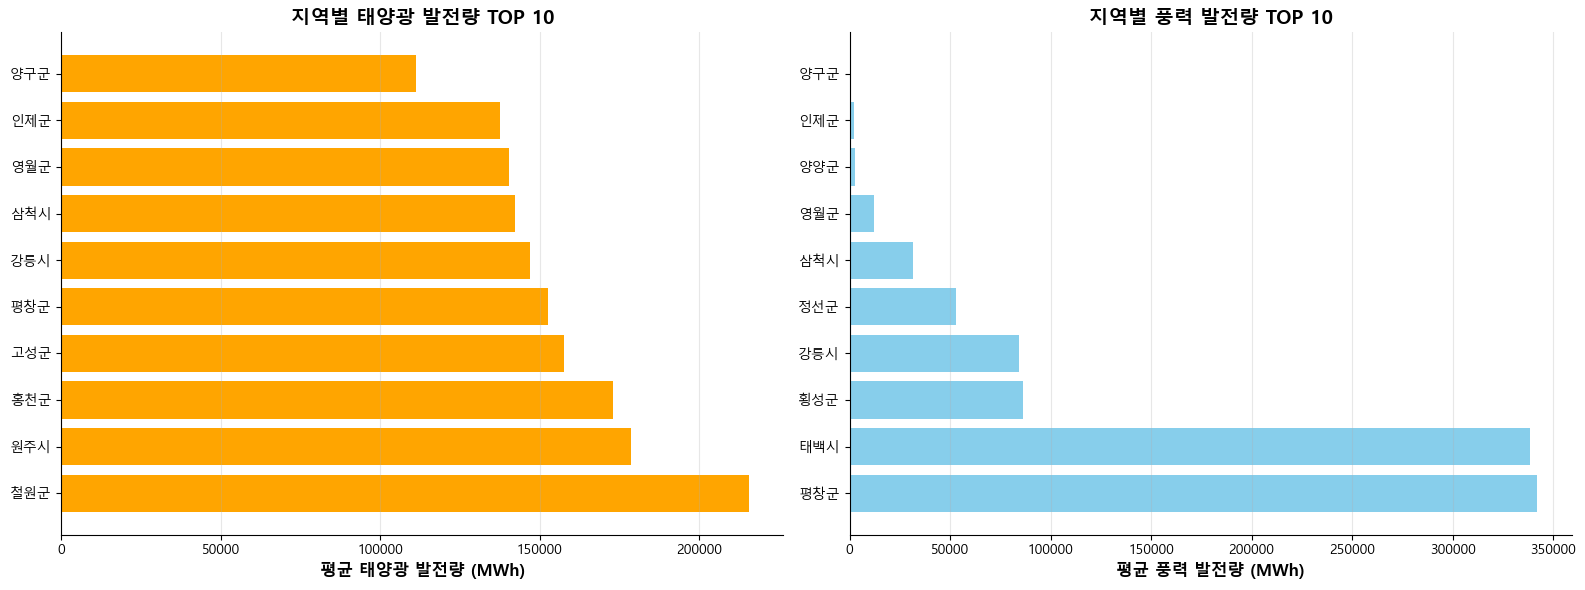


✅ 모든 추가 분석이 완료되었습니다!

생성된 파일:
  1. 계절별_상관관계_분석.png
  2. 다중회귀분석_태양광.png
  3. 지역별_발전량_비교.png


In [ ]:
print("\n" + "="*80)
print("🗺️ 지역별 발전 효율성 비교")
print("="*80)

# 지역별 발전량과 기후 요인 평균
regional_summary = merged.groupby('기초지자체_x').agg({
    '태양광': 'mean',
    '풍력': 'mean',
    '수력': 'mean',
    '일사합(MJ/m2)': 'mean',
    '평균풍속(m/s)': 'mean',
    '강수량(mm)': 'mean'
}).reset_index()

regional_summary = regional_summary[regional_summary['기초지자체_x'] != '기타']

# 발전 효율 계산 (발전량 / 기후 자원)
regional_summary['태양광_효율'] = regional_summary['태양광'] / regional_summary['일사합(MJ/m2)']
regional_summary['풍력_효율'] = regional_summary['풍력'] / regional_summary['평균풍속(m/s)']

# 상위 5개 지역
top_solar = regional_summary.nlargest(5, '태양광_효율')[['기초지자체_x', '태양광', '일사합(MJ/m2)', '태양광_효율']]
top_wind = regional_summary.nlargest(5, '풍력_효율')[['기초지자체_x', '풍력', '평균풍속(m/s)', '풍력_효율']]

print("\n🏆 태양광 발전 효율 상위 5개 지역:")
print(top_solar.to_string(index=False))

print("\n🏆 풍력 발전 효율 상위 5개 지역:")
print(top_wind.to_string(index=False))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 태양광
top_solar_plot = regional_summary.nlargest(10, '태양광')
axes[0].barh(top_solar_plot['기초지자체_x'], top_solar_plot['태양광'],
            color='orange', edgecolor='none')
axes[0].set_xlabel('평균 태양광 발전량 (MWh)', fontsize=12, fontweight='bold')
axes[0].set_title('지역별 태양광 발전량 TOP 10', fontsize=14, fontweight='bold')
axes[0].grid(True, axis='x', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# 풍력
top_wind_plot = regional_summary.nlargest(10, '풍력')
axes[1].barh(top_wind_plot['기초지자체_x'], top_wind_plot['풍력'],
            color='skyblue', edgecolor='none')
axes[1].set_xlabel('평균 풍력 발전량 (MWh)', fontsize=12, fontweight='bold')
axes[1].set_title('지역별 풍력 발전량 TOP 10', fontsize=14, fontweight='bold')
axes[1].grid(True, axis='x', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(r'C:\Users\dkreh\Desktop\KDT_RE_5th\3_Project\01_DataAnalysis\results\figures지역별_발전량_비교.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ 모든 추가 분석이 완료되었습니다!")
print("\n생성된 파일:")
print("  1. 계절별_상관관계_분석.png")
print("  2. 다중회귀분석_태양광.png")
print("  3. 지역별_발전량_비교.png")

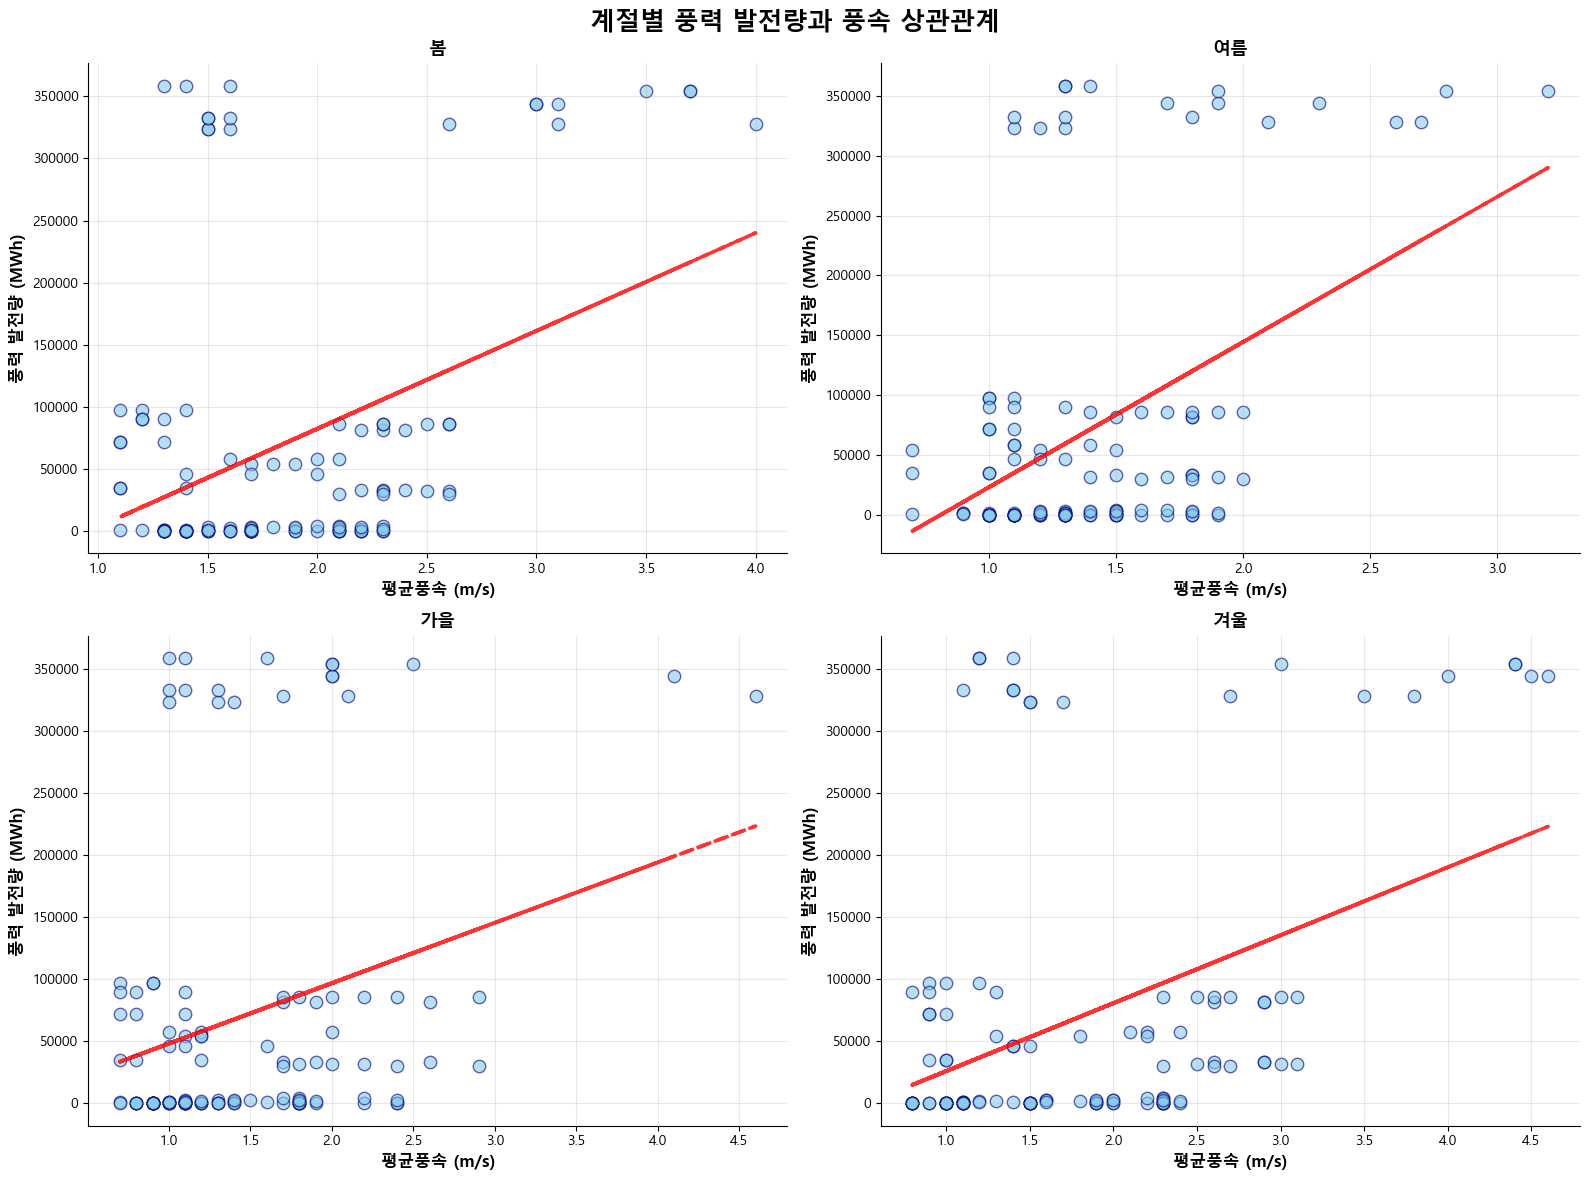

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

seasons = ['봄', '여름', '가을', '겨울']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('계절별 풍력 발전량과 풍속 상관관계',
             fontsize=18, fontweight='bold', y=0.98)

for idx, season in enumerate(seasons):
    ax = axes[idx//2, idx%2]
    
    # 계절별 데이터 필터링
    season_data = merged_monthly[merged_monthly['계절'] == season]
    wind_season = season_data.dropna(subset=['풍력', '평균풍속(m/s)'])
    
    if len(wind_season) > 3:
        # 산점도
        ax.scatter(wind_season['평균풍속(m/s)'], wind_season['풍력'],
                   alpha=0.6, s=80, c='skyblue', edgecolors='navy')
        
        # 추세선
        z = np.polyfit(wind_season['평균풍속(m/s)'], wind_season['풍력'], 1)
        p = np.poly1d(z)
        ax.plot(wind_season['평균풍속(m/s)'], p(wind_season['평균풍속(m/s)']),
                "r--", alpha=0.8, linewidth=2.5)
        
        # 축 라벨
        ax.set_xlabel('평균풍속 (m/s)', fontsize=12, fontweight='bold')
        ax.set_ylabel('풍력 발전량 (MWh)', fontsize=12, fontweight='bold')
        
        # 🔽 제목은 계절 이름만
        ax.set_title(season, fontsize=13, fontweight='bold')
        
        # 스타일
        ax.grid(True, alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

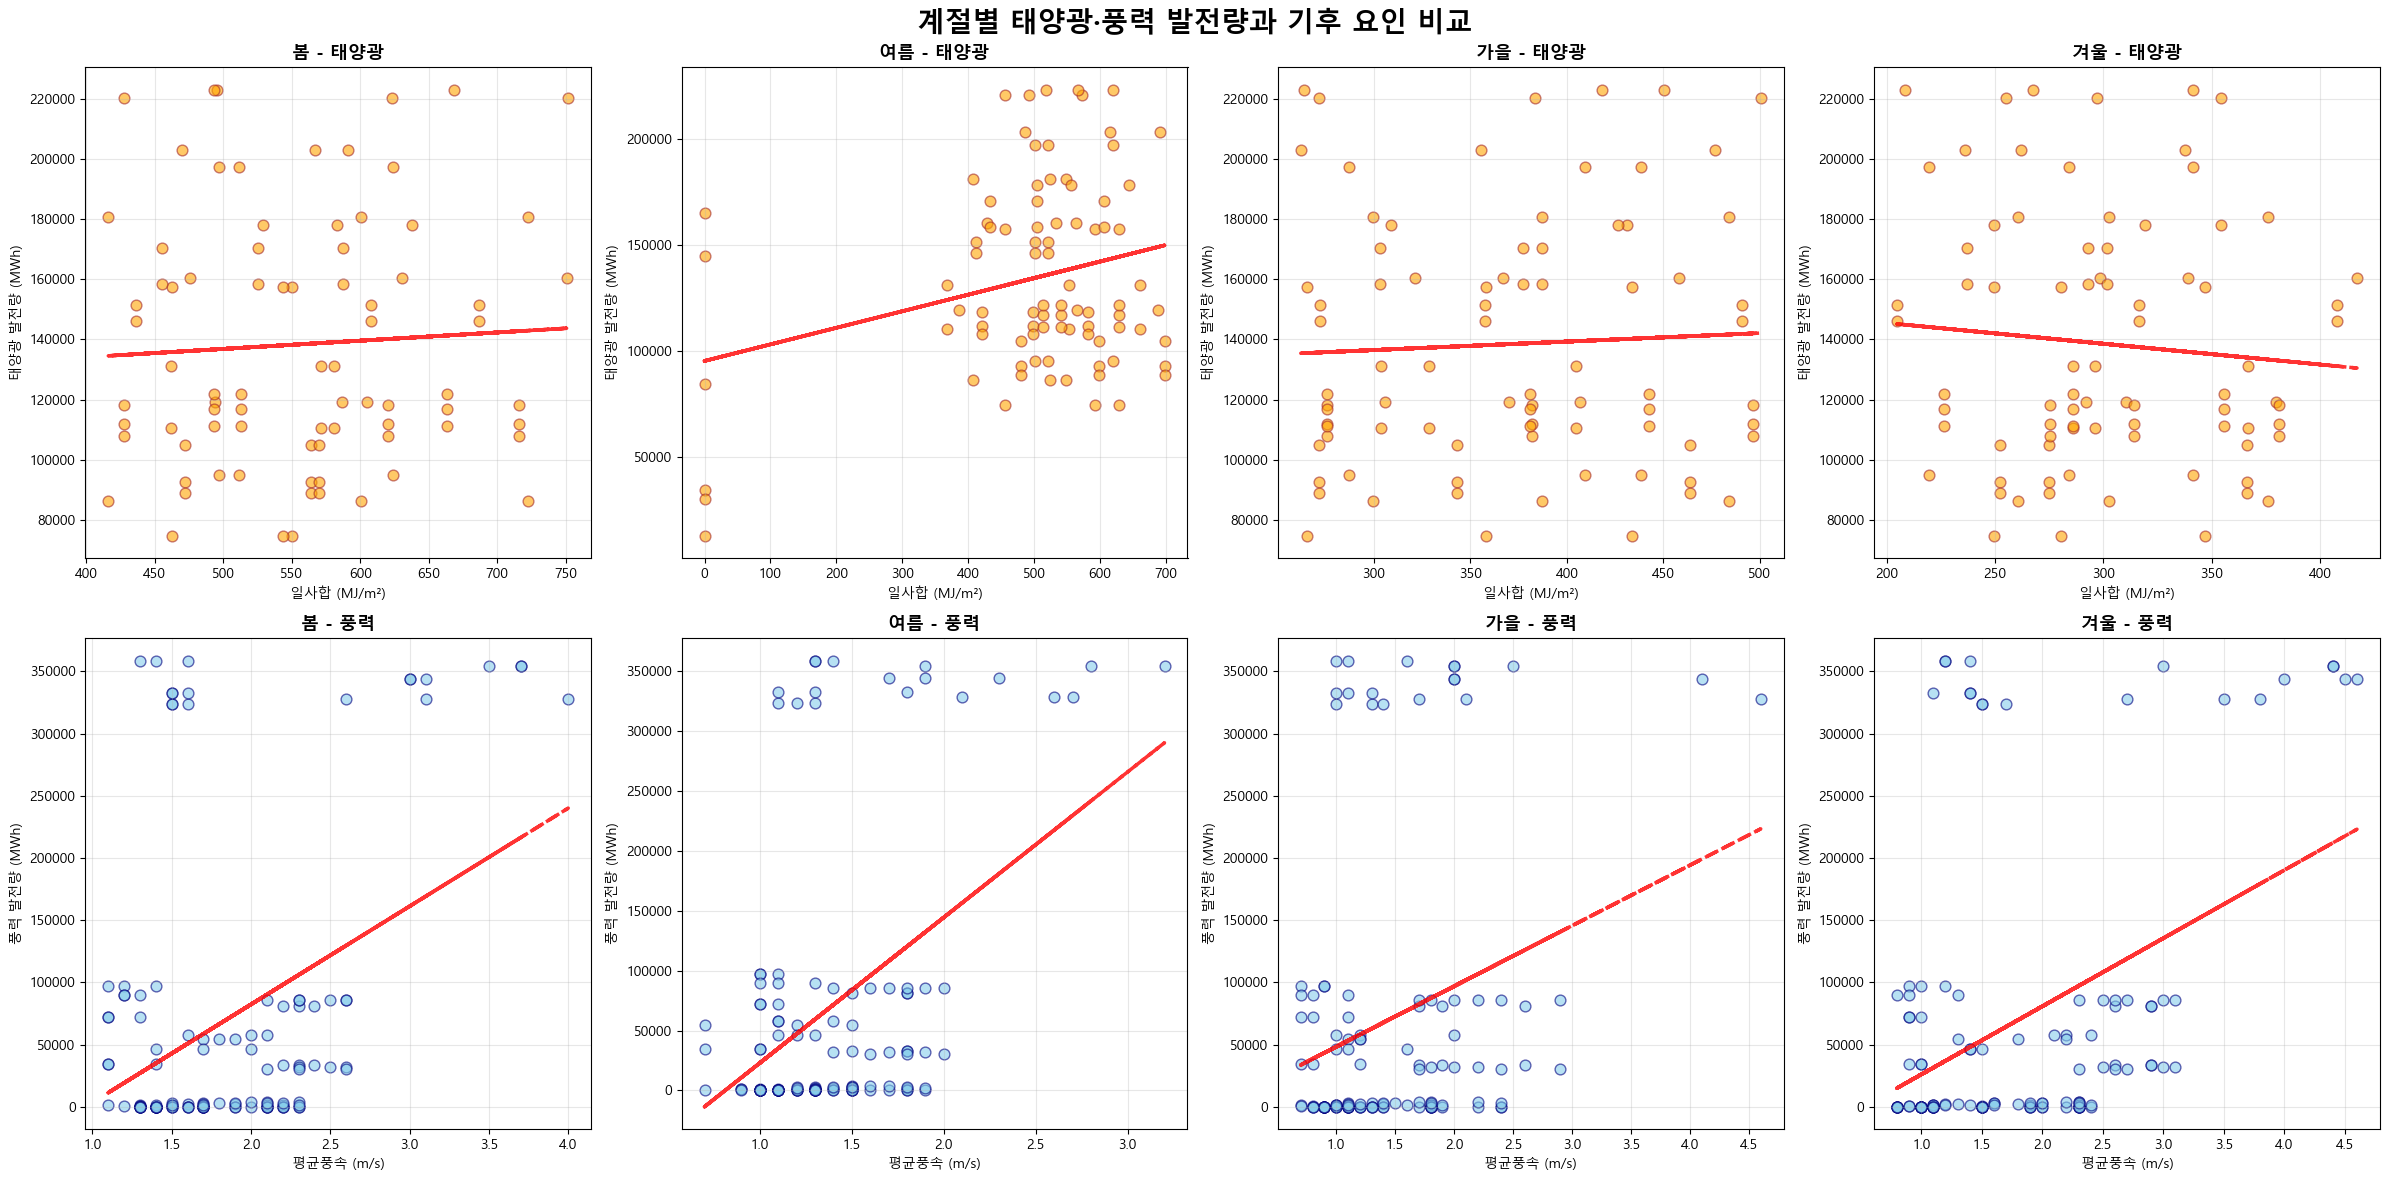

In [28]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

seasons = ['봄', '여름', '가을', '겨울']

fig, axes = plt.subplots(2, 4, figsize=(24, 12))
fig.suptitle('계절별 태양광·풍력 발전량과 기후 요인 비교', fontsize=20, fontweight='bold', y=0.98)

for idx, season in enumerate(seasons):
    # 태양광 vs 일사량
    ax1 = axes[0, idx]
    season_data = merged_monthly[merged_monthly['계절'] == season]
    solar_season = season_data.dropna(subset=['태양광', '일사합(MJ/m2)'])
    if len(solar_season) > 3:
        ax1.scatter(solar_season['일사합(MJ/m2)'], solar_season['태양광'],
                    alpha=0.6, s=60, c='orange', edgecolors='brown')
        z = np.polyfit(solar_season['일사합(MJ/m2)'], solar_season['태양광'], 1)
        p = np.poly1d(z)
        ax1.plot(solar_season['일사합(MJ/m2)'], p(solar_season['일사합(MJ/m2)']),
                 "r--", alpha=0.8, linewidth=2.5)
        ax1.set_title(f'{season} - 태양광', fontsize=13, fontweight='bold')
        ax1.set_xlabel('일사합 (MJ/m²)')
        ax1.set_ylabel('태양광 발전량 (MWh)')
        ax1.grid(True, alpha=0.3)

    # 풍력 vs 풍속
    ax2 = axes[1, idx]
    wind_season = season_data.dropna(subset=['풍력', '평균풍속(m/s)'])
    if len(wind_season) > 3:
        ax2.scatter(wind_season['평균풍속(m/s)'], wind_season['풍력'],
                    alpha=0.6, s=60, c='skyblue', edgecolors='navy')
        z = np.polyfit(wind_season['평균풍속(m/s)'], wind_season['풍력'], 1)
        p = np.poly1d(z)
        ax2.plot(wind_season['평균풍속(m/s)'], p(wind_season['평균풍속(m/s)']),
                 "r--", alpha=0.8, linewidth=2.5)
        ax2.set_title(f'{season} - 풍력', fontsize=13, fontweight='bold')
        ax2.set_xlabel('평균풍속 (m/s)')
        ax2.set_ylabel('풍력 발전량 (MWh)')
        ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
! pip install qrcode[pil]

Note: you may need to restart the kernel to use updated packages.


In [32]:
# Generating QR code for GitHub Pages URL
import qrcode
import os

# URL to encode
url = "https://kimwjdhyun.github.io/KDT_RE_5th_Project/"

# Generate QR code
qr = qrcode.make(url)

# Ensure output directory exists
output_path = r"C:\Users\dkreh\Desktop\KDT_RE_5th\3_Project\01_DataAnalysis\results\figures/github_project_qr.png"
qr.save(output_path)

print("QR 코드가 생성되었습니다: github_project_qr.png")

QR 코드가 생성되었습니다: github_project_qr.png
